In [1]:
# --- Импорт библиотек ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [2]:
# --- Загрузка данных ---
df = pd.read_excel("../Models/Лошади/Датасет по лошадям v2.xlsx")

In [3]:
# --- Первичный осмотр ---
print("Общий вид данных:")
display(df.head())

Общий вид данных:


,Регион,Период,Лошади
0,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-01,1292.32
1,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-02,704.43
2,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-03,721.88
3,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-04,742.10
4,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-05,1041.54


In [4]:
print("\nОбщая информация:")
print(df.info())


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108 entries, 0 to 2107
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регион  2108 non-null   object 
 1   Период  2108 non-null   object 
 2   Лошади  2108 non-null   float64
dtypes: float64(1), object(2)
memory usage: 49.5+ KB
None


In [5]:
# --- Проверка пропусков и дубликатов ---
print("Пропуски по столбцам:")
print(df.isnull().sum())
print("Количество дубликатов:", df.duplicated().sum())

Пропуски по столбцам:
Регион    0
Период    0
Лошади    0
dtype: int64
Количество дубликатов: 0


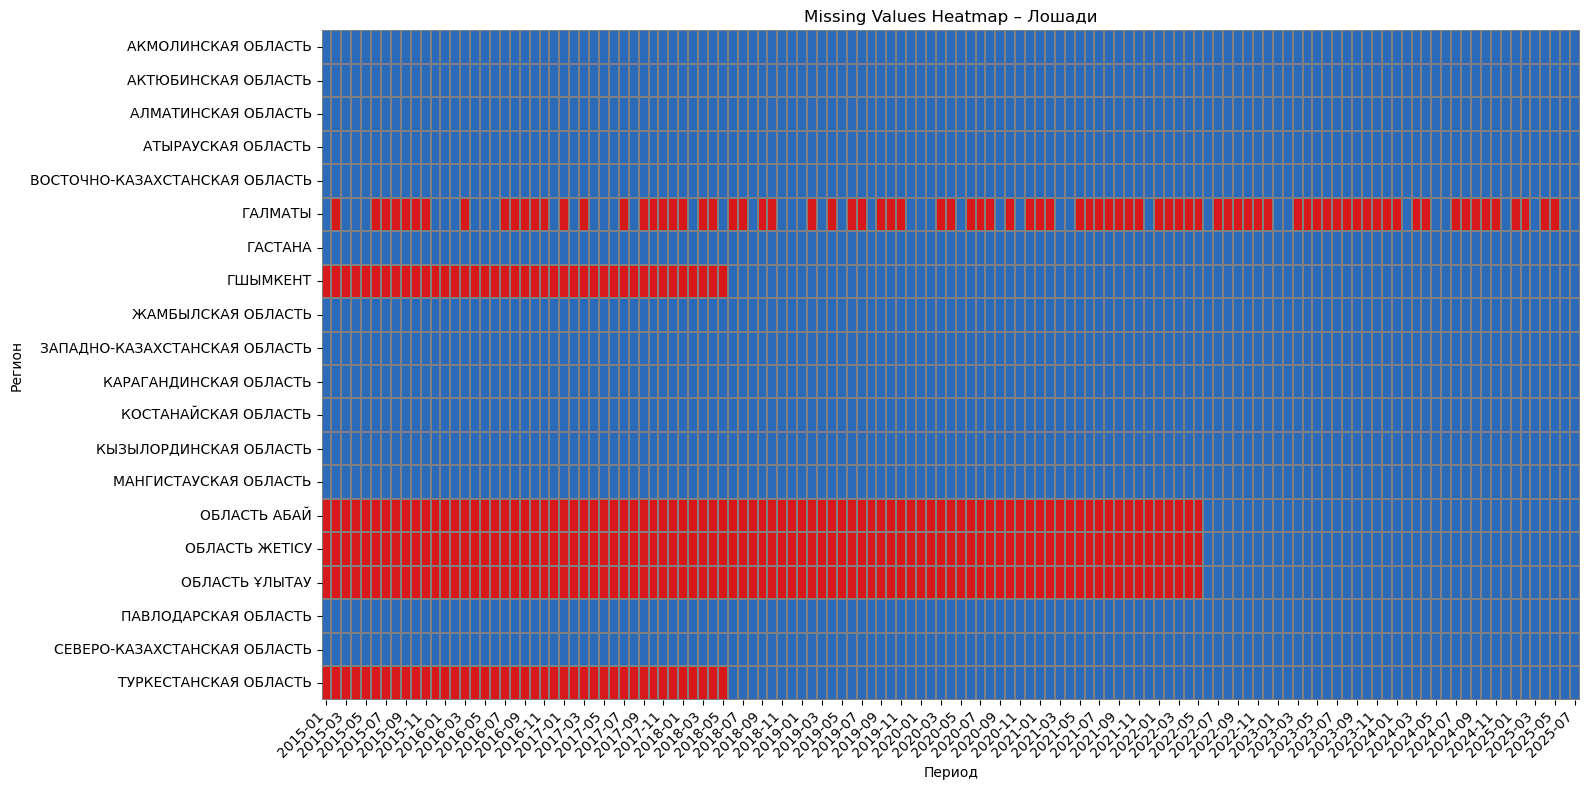

In [6]:
# === Тепловая карта пропусков с корректными датами на оси X ===
value_col = "Лошади"

df_plot = df.copy()
df_plot["Период"] = pd.to_datetime(df_plot["Период"]).dt.to_period("M").dt.to_timestamp()

mat = (
    df_plot.pivot_table(index="Регион", columns="Период", values=value_col, aggfunc="mean")
          .sort_index()
          .sort_index(axis=1)
)

missing_matrix = mat.isna().astype(int)

# --- преобразуем колонки (даты) в формат YYYY-MM ---
missing_matrix.columns = missing_matrix.columns.strftime("%Y-%m")

plt.figure(figsize=(16, 8))
sns.heatmap(
    missing_matrix,
    cmap=["#2b6bba", "#d7191c"],
    cbar=False,
    linewidths=0.3,
    linecolor="grey"
)
plt.title(f"Missing Values Heatmap – {value_col}")
plt.xlabel("Период")
plt.ylabel("Регион")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
print("\nОбщее описание по всему датасету:")
display(df.describe())


Общее описание по всему датасету:


,Лошади
count,2108.000000
mean,1299.197386
std,1303.691395
min,0.370000
25%,458.610000
50%,962.485000
75%,1711.505000
max,9619.600000


In [8]:
# --- Описание по каждому региону ---
print("\nОписание по регионам:")
region_stats = df.groupby("Регион")["Лошади"].describe()
display(region_stats)


Описание по регионам:


,count,mean,std,min,25%,50%,75%,max
Регион,,,,,,,,
АКМОЛИНСКАЯ ОБЛАСТЬ,127.0,1243.664882,417.496485,704.43,911.2650,1068.990,1633.1100,2212.19
АКТЮБИНСКАЯ ОБЛАСТЬ,127.0,1636.817008,1003.233952,515.91,1017.5000,1422.490,1815.0300,5123.90
АЛМАТИНСКАЯ ОБЛАСТЬ,127.0,2440.637008,1708.046717,349.43,1004.6450,1959.690,3413.9450,7800.32
АТЫРАУСКАЯ ОБЛАСТЬ,127.0,797.862835,519.451232,282.69,517.4650,638.220,874.5900,2842.00
ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,127.0,2736.951339,1606.142922,537.16,1590.5700,2286.540,3612.5000,7244.11
ГАЛМАТЫ,44.0,5.038636,8.550955,0.37,0.4000,1.500,5.9200,36.63
ГАСТАНА,127.0,3.740079,2.822976,0.60,2.3650,3.080,4.1600,20.04
ГШЫМКЕНТ,86.0,55.060581,67.405075,13.20,30.7200,42.380,60.2250,614.17
ЖАМБЫЛСКАЯ ОБЛАСТЬ,127.0,1306.056535,428.285442,440.21,947.1500,1345.170,1534.2000,2303.53


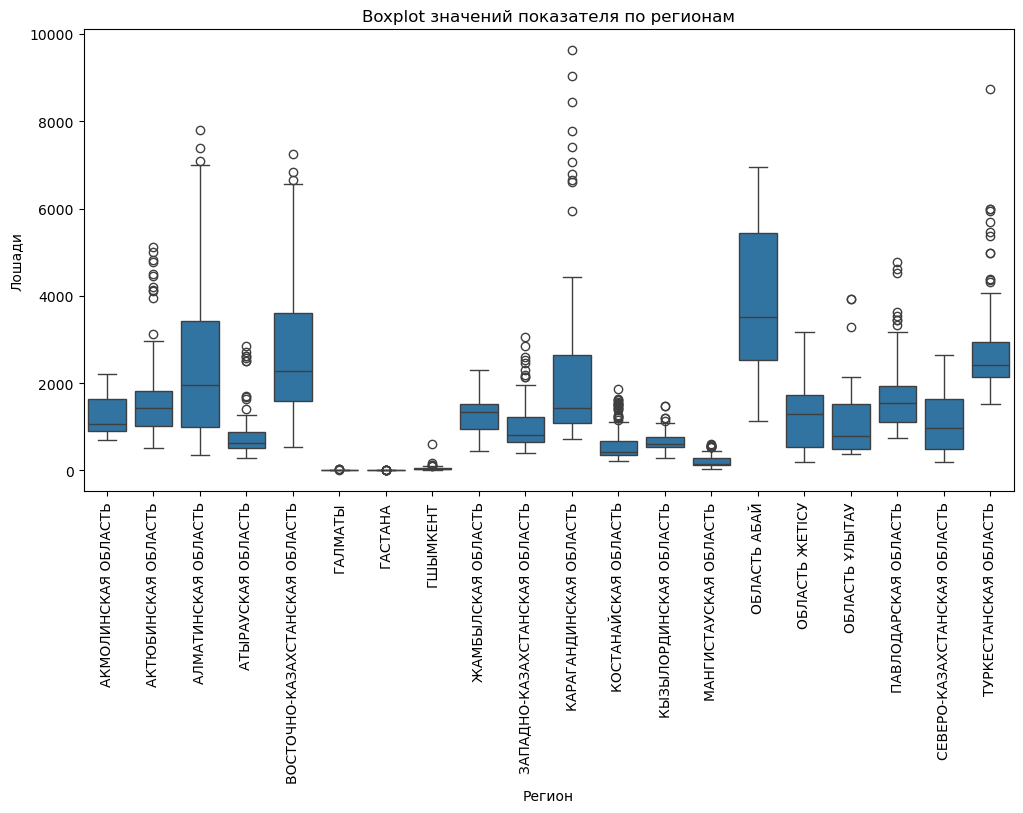

In [9]:
# Визуализация размаха значений по регионам
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Регион", y="Лошади")
plt.xticks(rotation=90)
plt.title("Boxplot значений показателя по регионам")
plt.show()

In [10]:
# --- Описание по регионам и годам ---
df["Период"] = pd.to_datetime(df["Период"])
df_copy = df.copy()
df_copy["Год"] = df_copy["Период"].dt.year

# Статистика по каждому региону и году
region_year_stats = (
    df_copy.groupby(["Регион", "Год"])["Лошади"]
      .describe()
      .reset_index()
)
display(region_year_stats)

,Регион,Год,count,mean,std,min,25%,50%,75%,max
0,АКМОЛИНСКАЯ ОБЛАСТЬ,2015,12.0,1165.643333,486.129659,704.43,779.5100,981.305,1396.3725,2098.27
1,АКМОЛИНСКАЯ ОБЛАСТЬ,2016,12.0,1164.850833,415.230691,743.16,872.2100,970.485,1441.0850,1843.35
2,АКМОЛИНСКАЯ ОБЛАСТЬ,2017,12.0,1188.246667,423.940935,780.08,871.9725,1014.380,1501.0200,1876.38
3,АКМОЛИНСКАЯ ОБЛАСТЬ,2018,12.0,1188.735833,412.160831,770.47,877.6725,1036.990,1496.3825,1875.91
4,АКМОЛИНСКАЯ ОБЛАСТЬ,2019,12.0,1225.700833,430.554578,785.52,890.2175,1071.180,1531.3175,1915.37
...,...,...,...,...,...,...,...,...,...,...
188,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2021,12.0,3001.214167,1218.694716,1602.75,2308.0575,2529.785,3252.0325,5698.73
189,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2022,12.0,2966.297500,1184.898784,1712.06,2367.2050,2448.870,3242.5350,5359.10
190,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2023,12.0,3304.520833,1322.430370,1819.02,2390.4500,2796.265,3819.6575,5994.34
191,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2024,12.0,3353.077500,2110.391572,1836.76,2088.0450,2294.110,4009.9050,8733.53


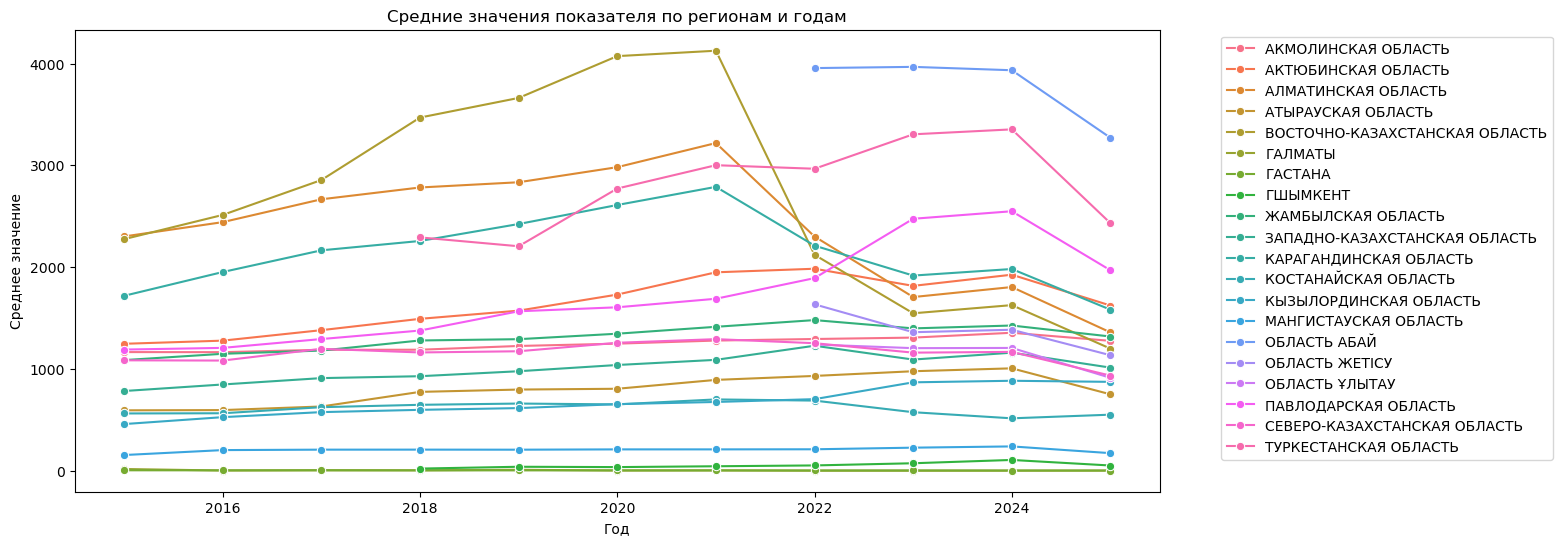

In [11]:
# Визуализация динамики среднего значения по годам
plt.figure(figsize=(14,6))
sns.lineplot(data=region_year_stats, x="Год", y="mean", hue="Регион", marker="o")
plt.title("Средние значения показателя по регионам и годам")
plt.ylabel("Среднее значение")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

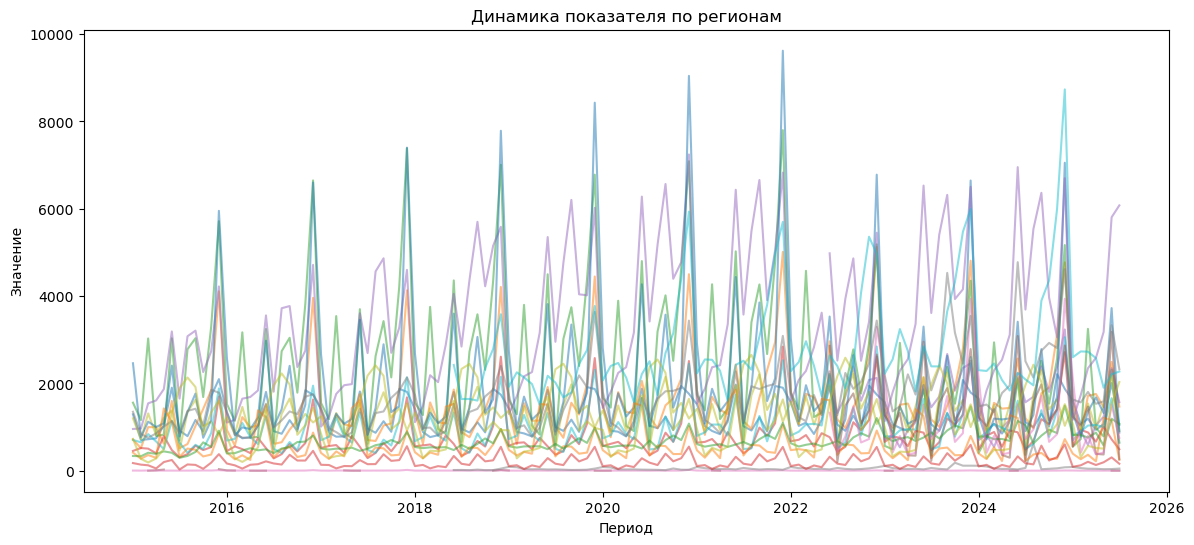

In [12]:
# --- Временной анализ по всем регионам ---
df["Период"] = pd.to_datetime(df["Период"])
df_region = df.pivot(index="Период", columns="Регион", values="Лошади")

plt.figure(figsize=(14,6))
for col in df_region.columns:
    plt.plot(df_region.index, df_region[col], alpha=0.5)
plt.title("Динамика показателя по регионам")
plt.xlabel("Период")
plt.ylabel("Значение")
plt.show()

### Оценка временных рядов,их стационарности

In [13]:
df

,Регион,Период,Лошади
0,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-01-01,1292.32
1,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-02-01,704.43
2,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-03-01,721.88
3,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-04-01,742.10
4,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-05-01,1041.54
...,...,...,...
2103,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-03-01,2726.66
2104,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-04-01,2579.69
2105,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-05-01,1902.11
2106,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-06-01,2208.35


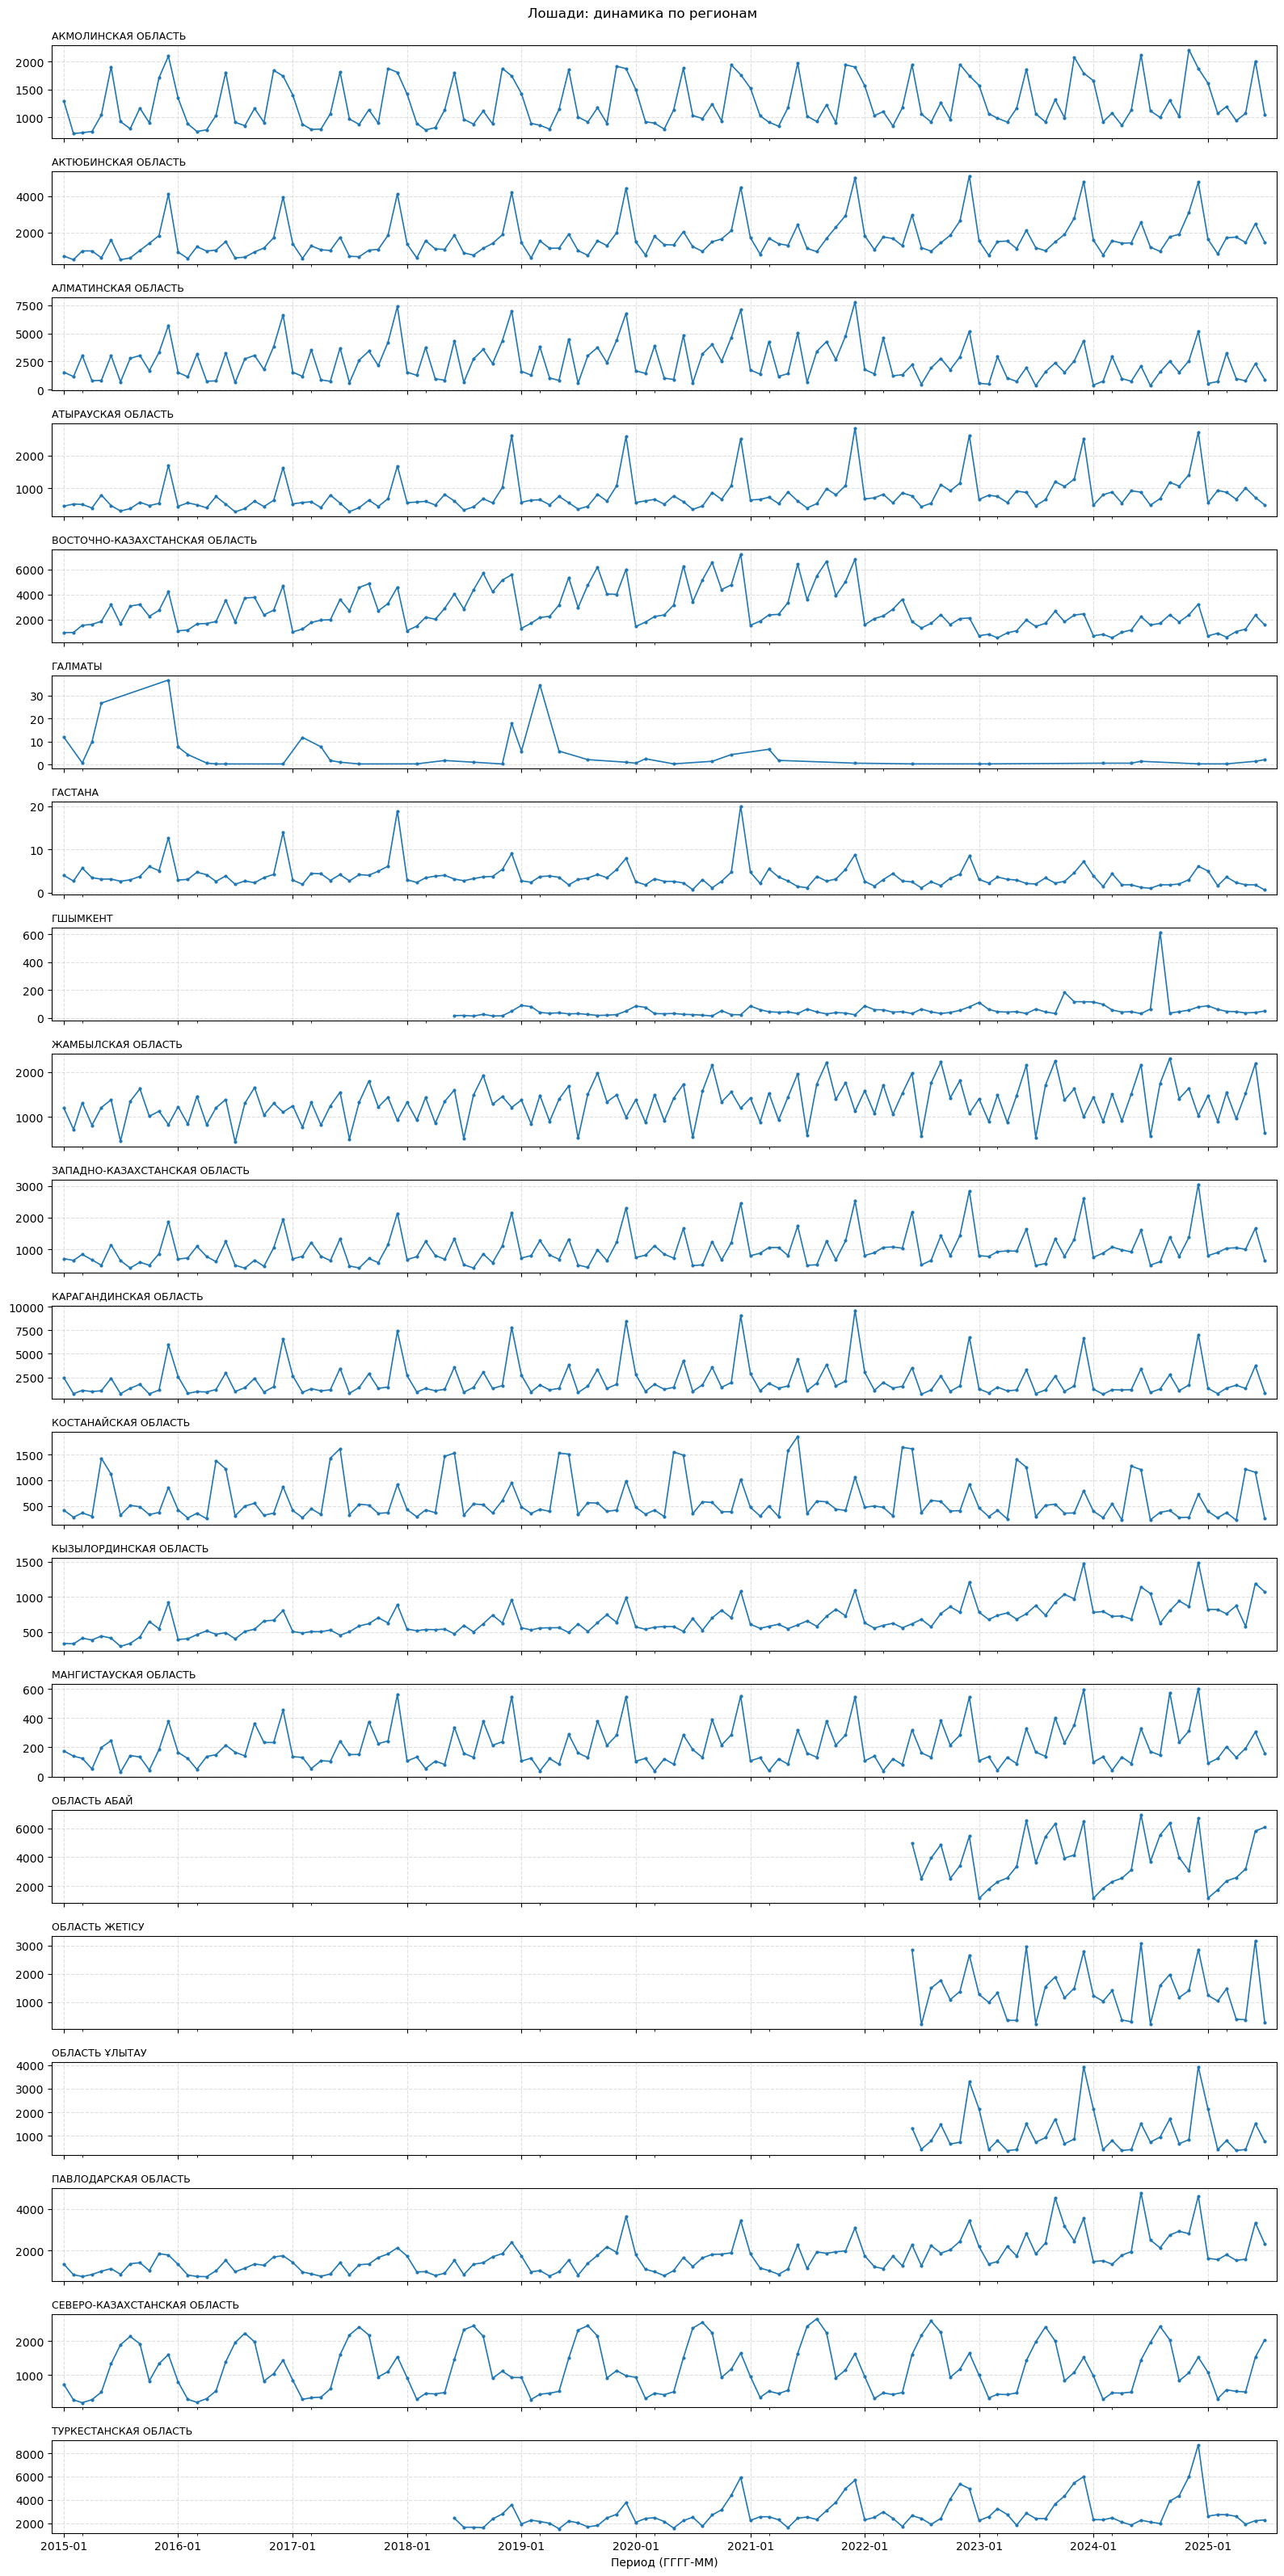

In [14]:
# --- Параметры ---
value_col = "Лошади"  # замените при необходимости на имя столбца с показателем

# --- Подготовка данных ---
df_plot = df.copy()
df_plot["Период"] = pd.to_datetime(df_plot["Период"]).dt.to_period("M").dt.to_timestamp()
df_plot = df_plot.sort_values(["Регион", "Период"])

regions = sorted(df_plot["Регион"].unique())
n = len(regions)

# --- Фигуры и оси ---
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter

h_per_ax = 1.6  # высота на один график
fig, axes = plt.subplots(n, 1, sharex=True, figsize=(16, max(4, n * h_per_ax)))
if n == 1:
    axes = [axes]

for ax, reg in zip(axes, regions):
    s = df_plot.loc[df_plot["Регион"] == reg, ["Период", value_col]].dropna(subset=["Период"])
    s = s.sort_values("Период")
    ax.plot(s["Период"], s[value_col], lw=1.2, marker="o", ms=2)
    ax.set_title(reg, loc="left", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.margins(x=0.01)

# Оформление оси времени: подписи как ГГГГ-ММ
axes[-1].xaxis.set_major_locator(YearLocator(1))
axes[-1].xaxis.set_major_formatter(DateFormatter("%Y-%m"))
axes[-1].xaxis.set_minor_locator(MonthLocator(3))  # минорные тики раз в 3 месяца

fig.suptitle(f"{value_col}: динамика по регионам", fontsize=12, y=0.995)
plt.xlabel("Период (ГГГГ-ММ)")
plt.tight_layout()
plt.show()


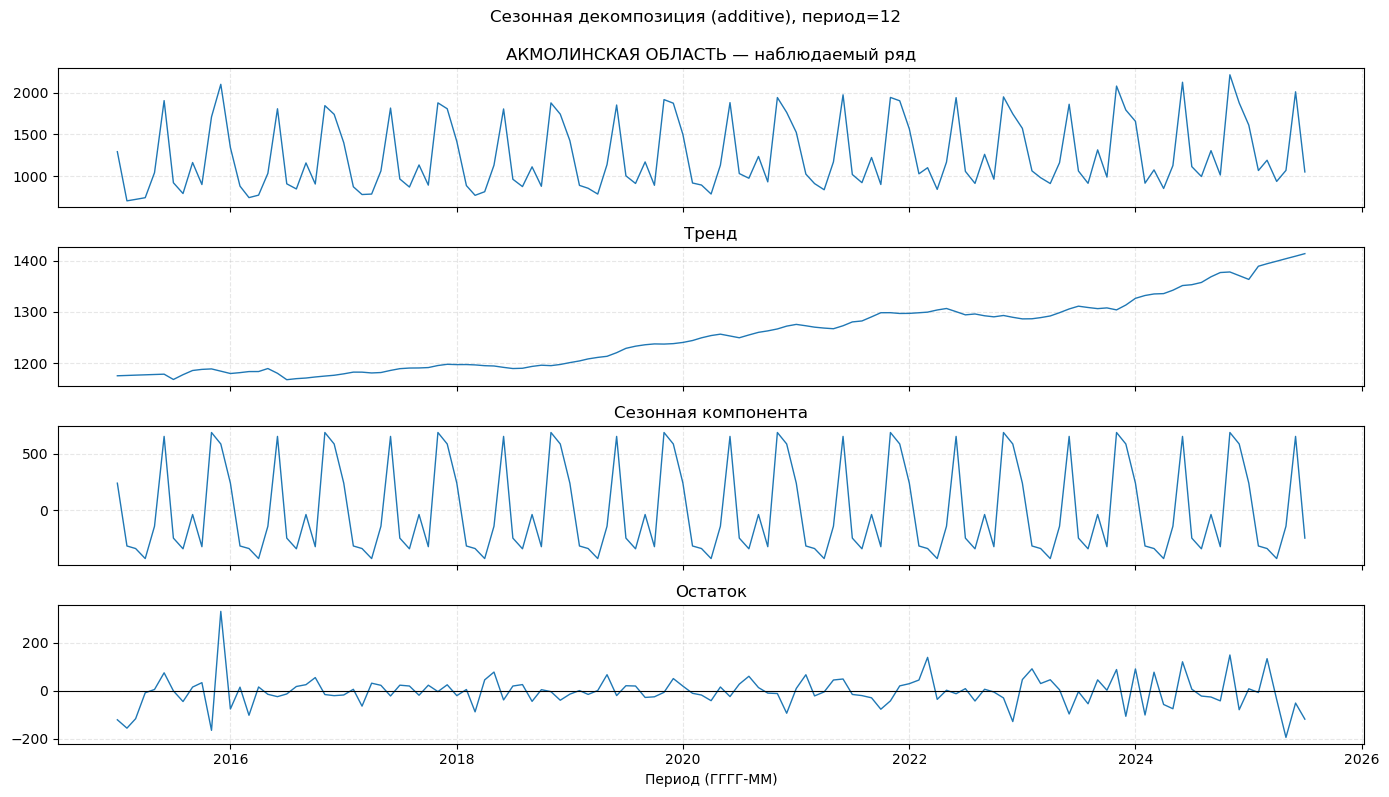

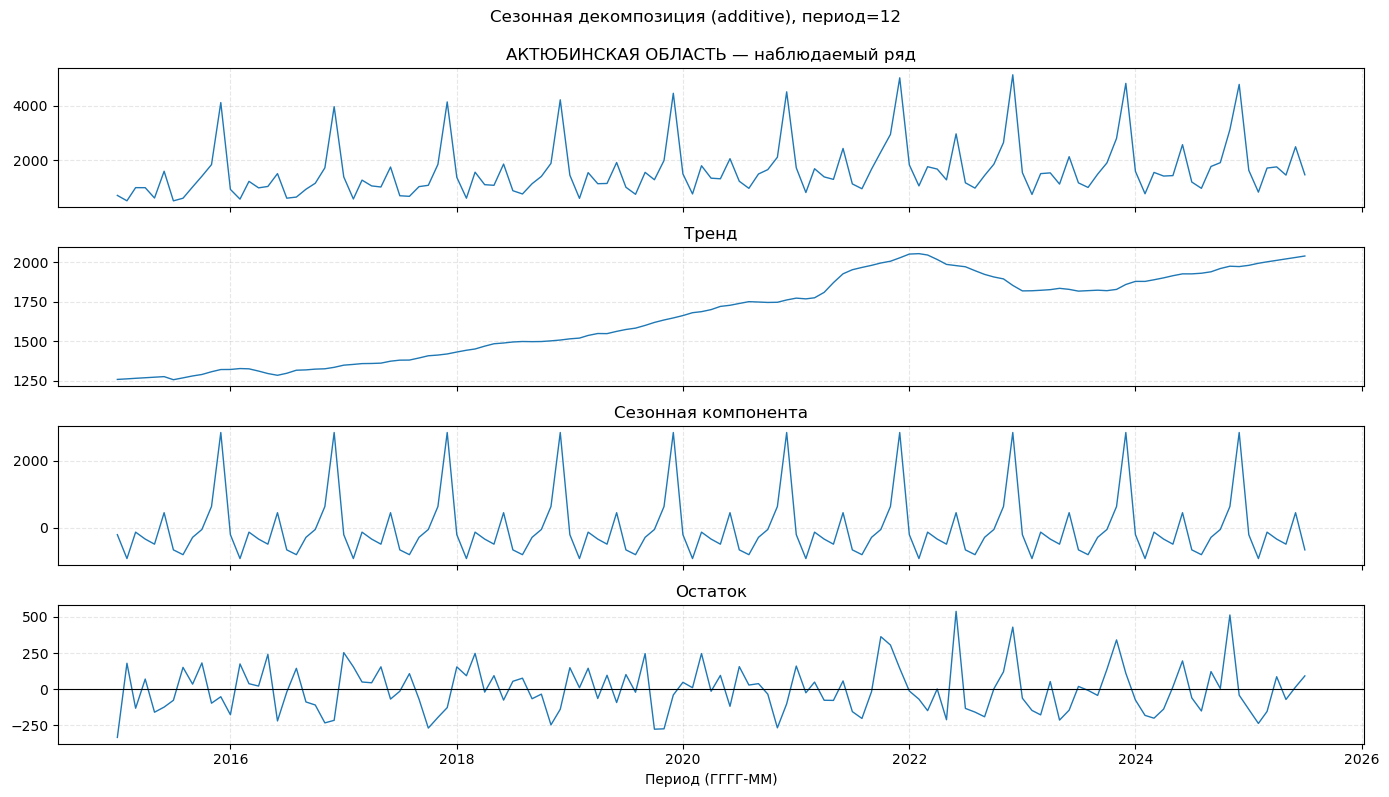

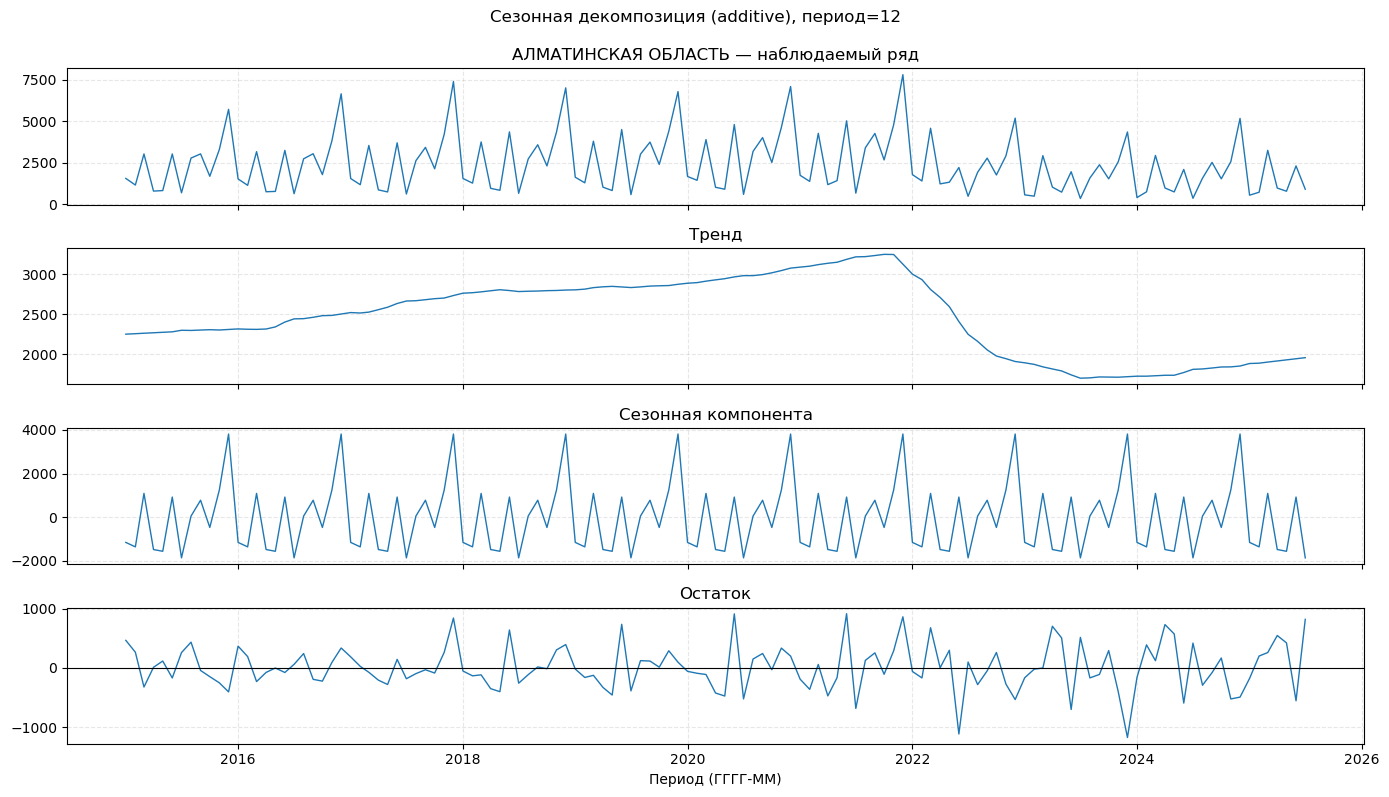

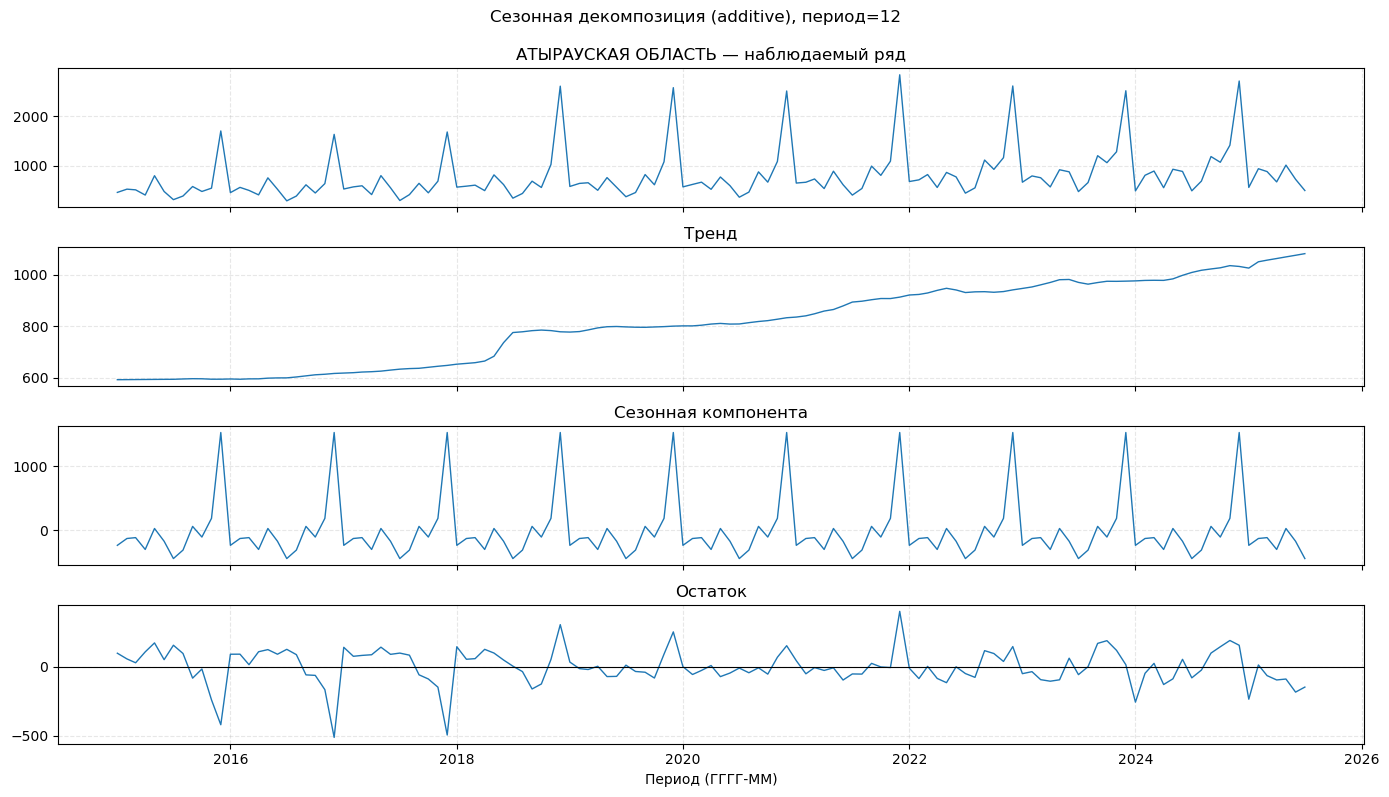

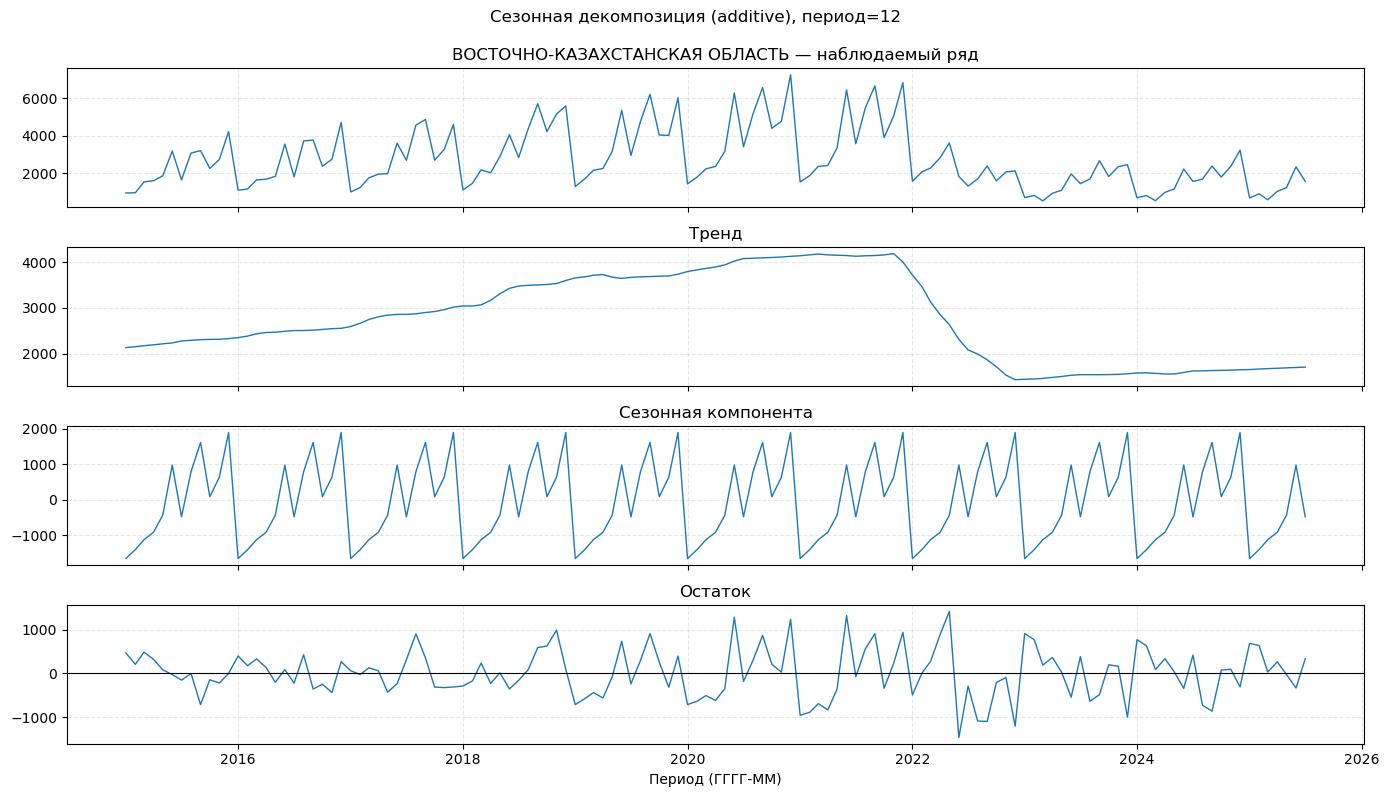

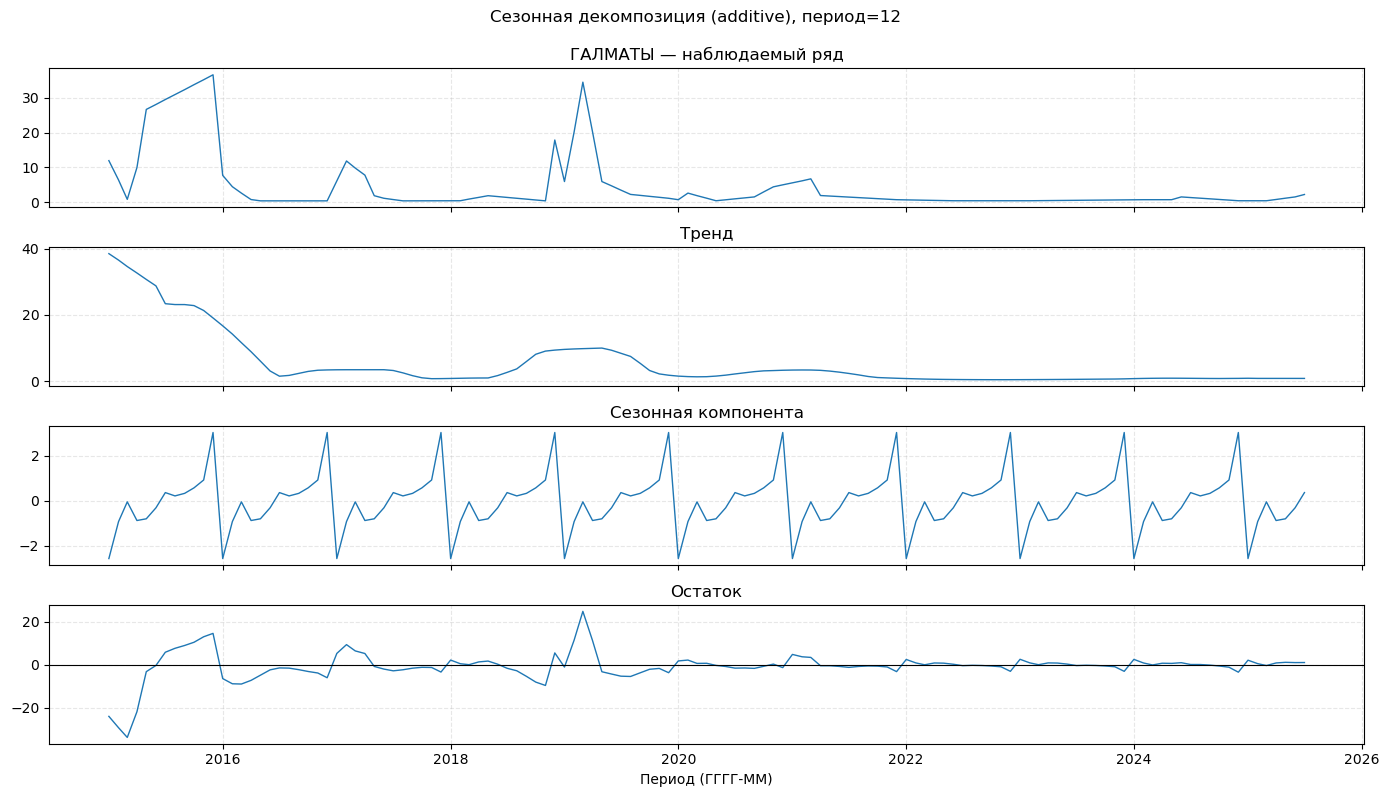

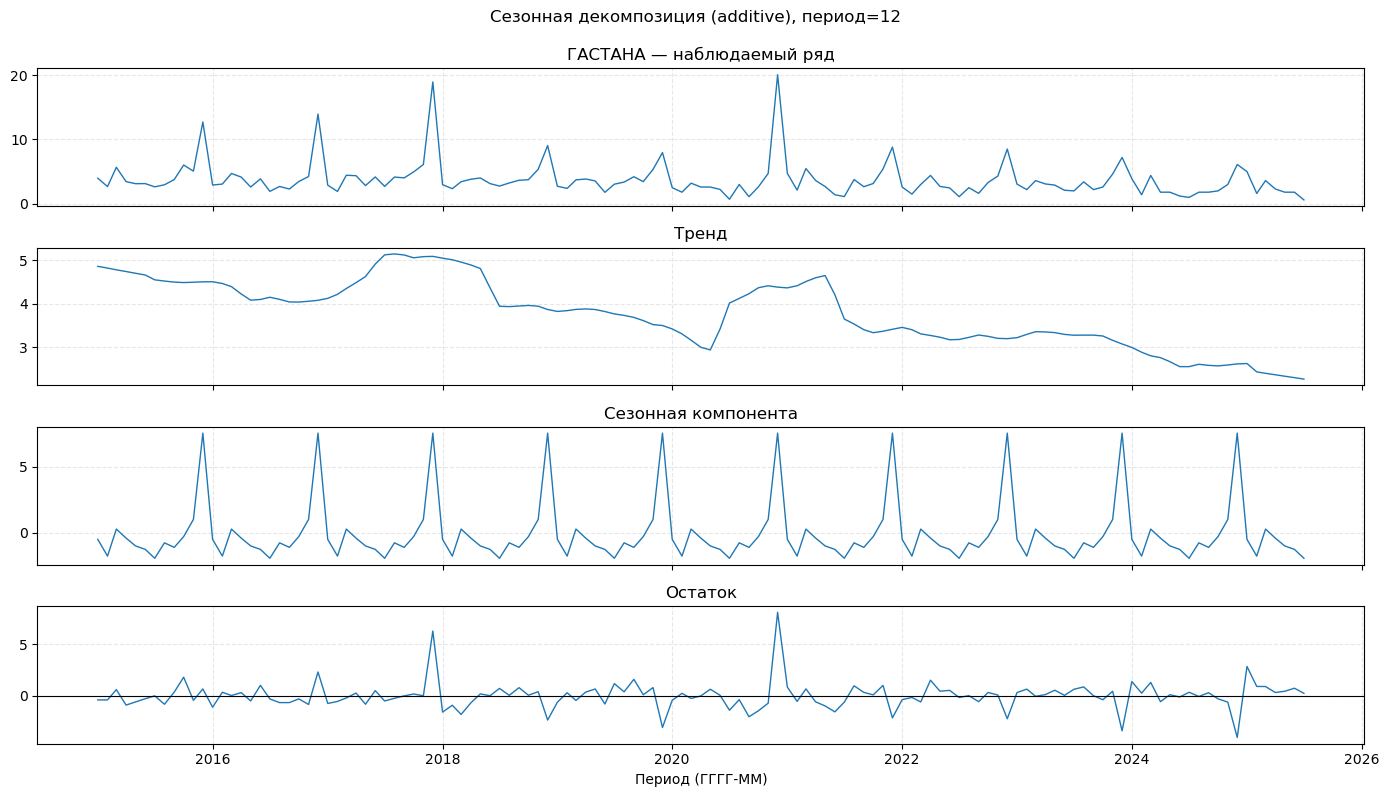

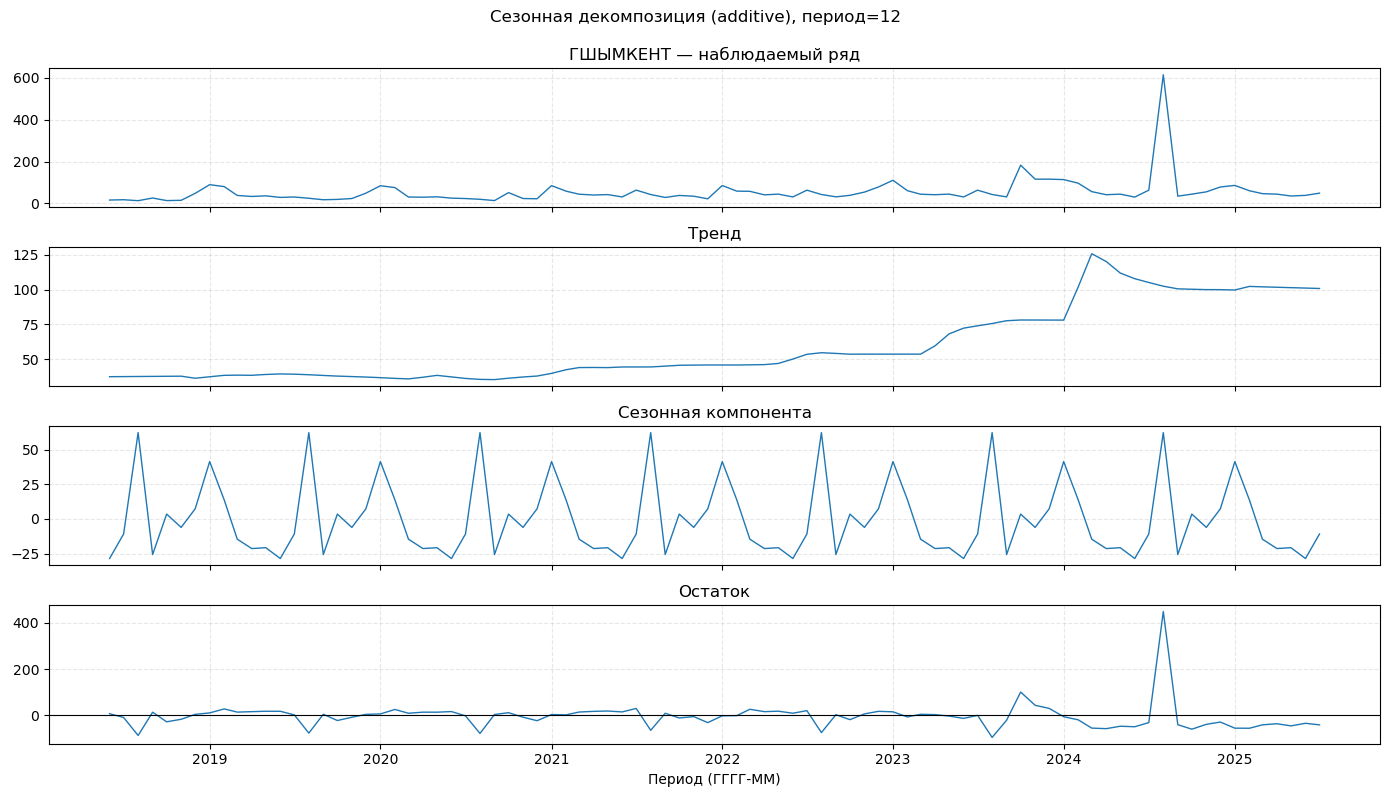

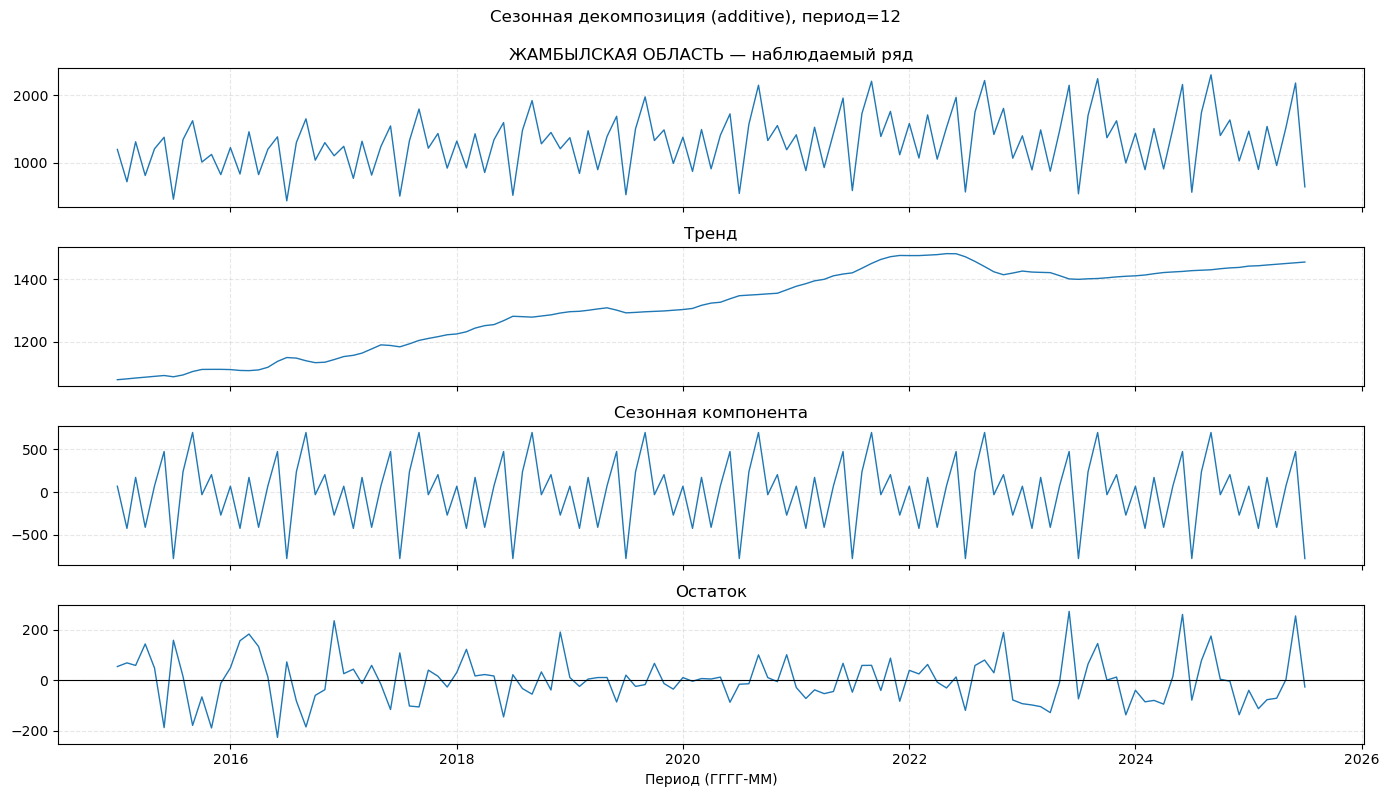

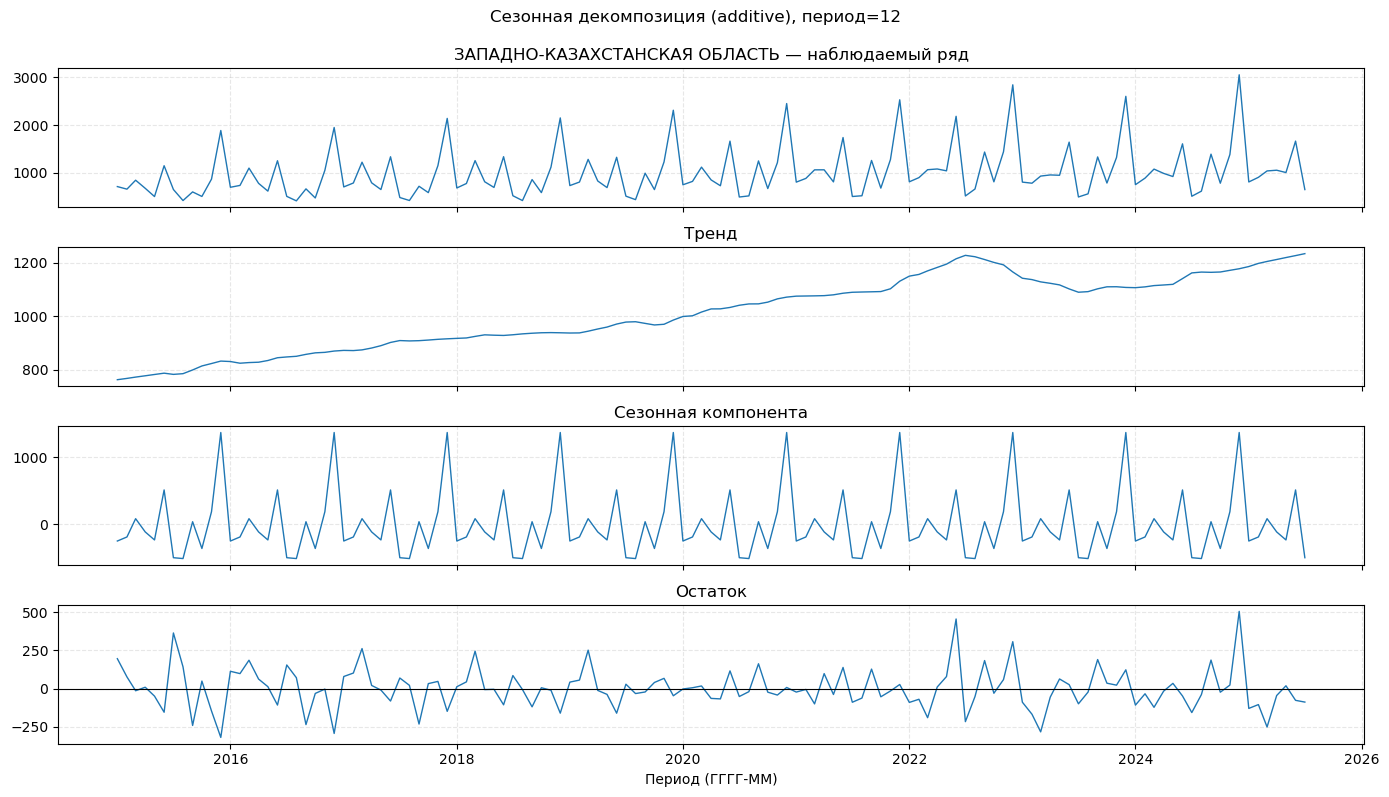

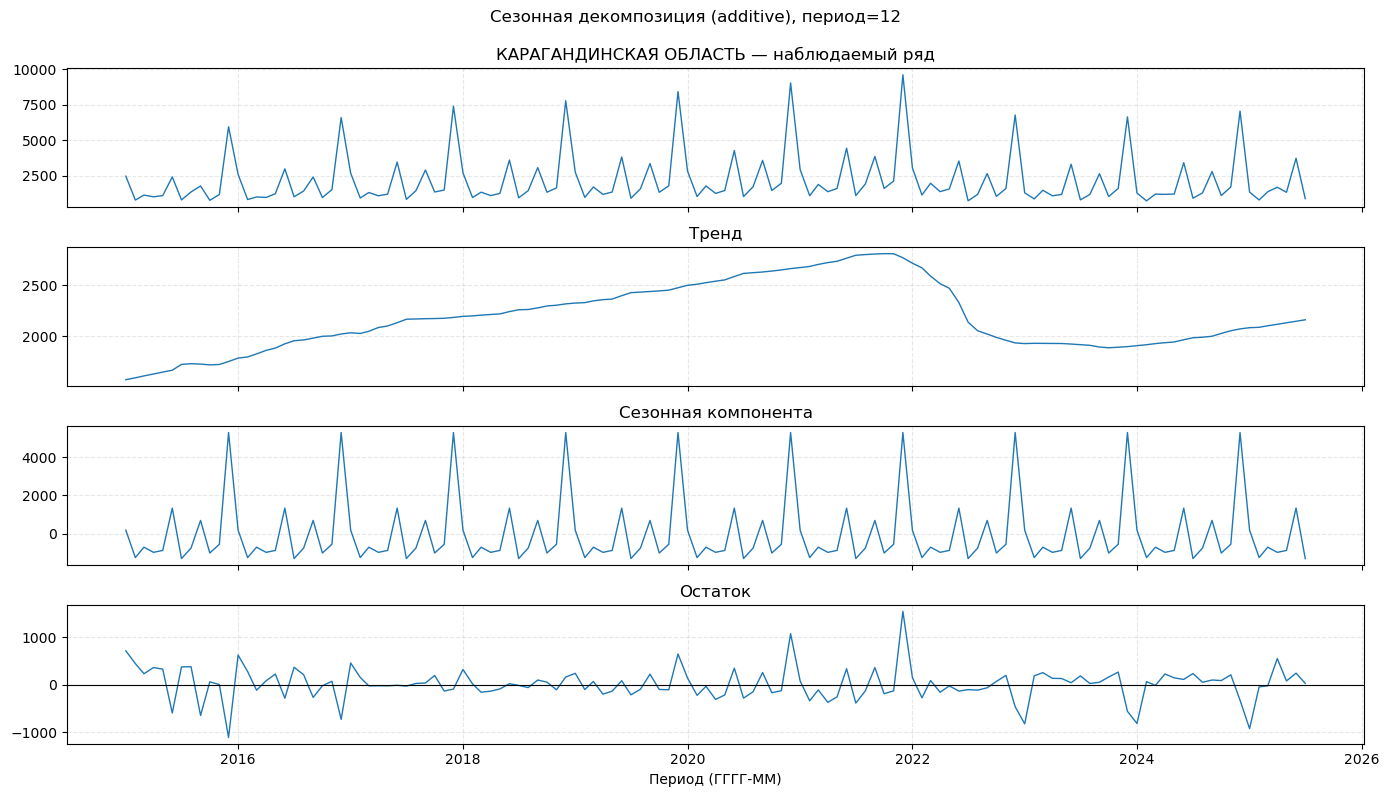

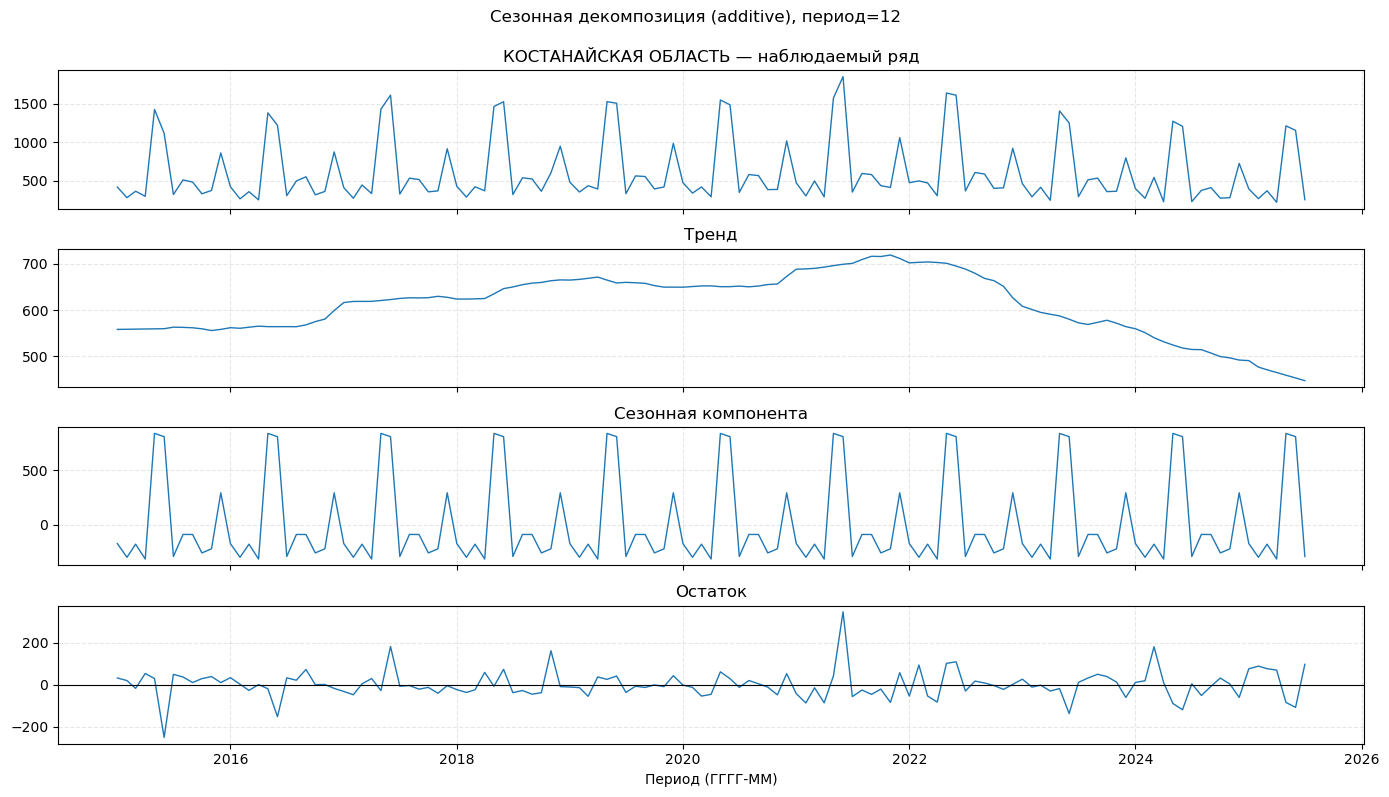

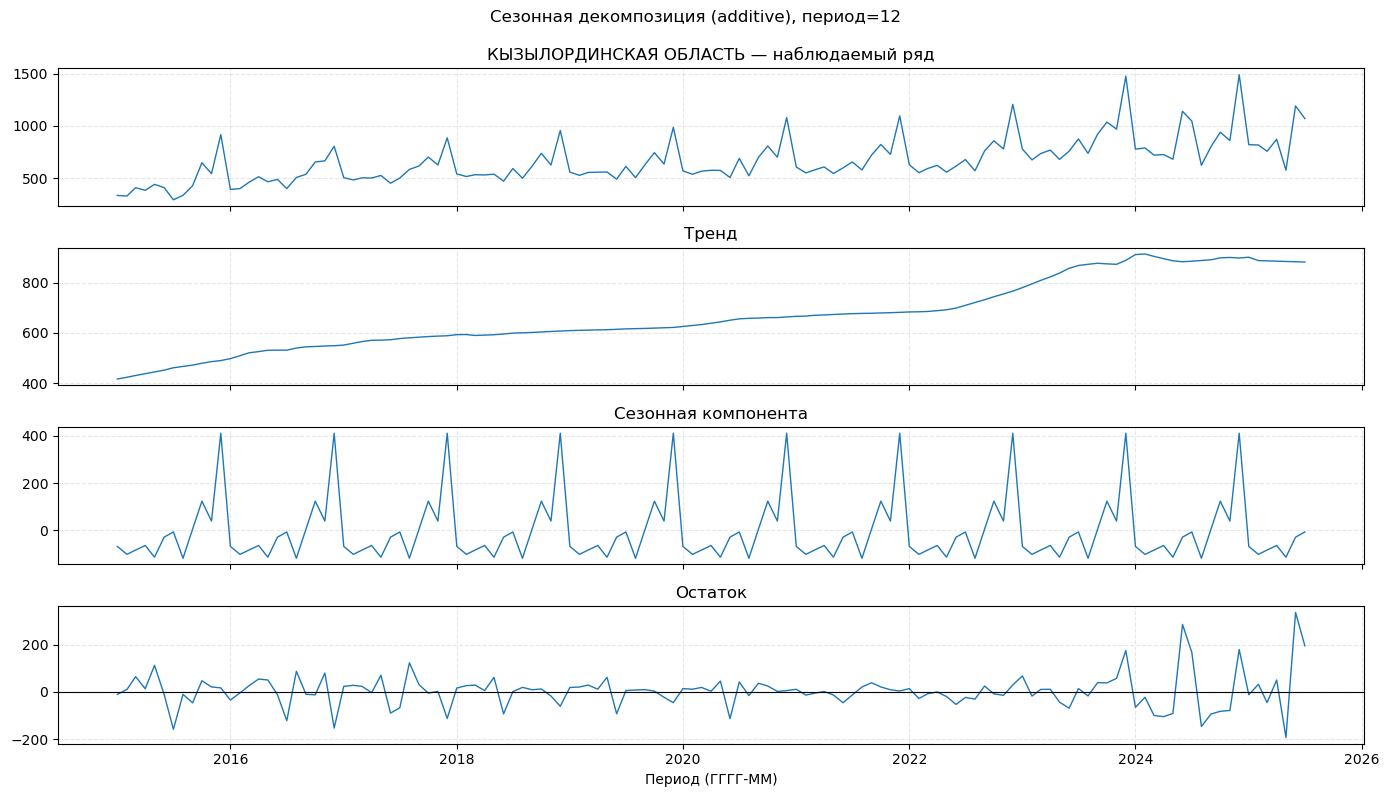

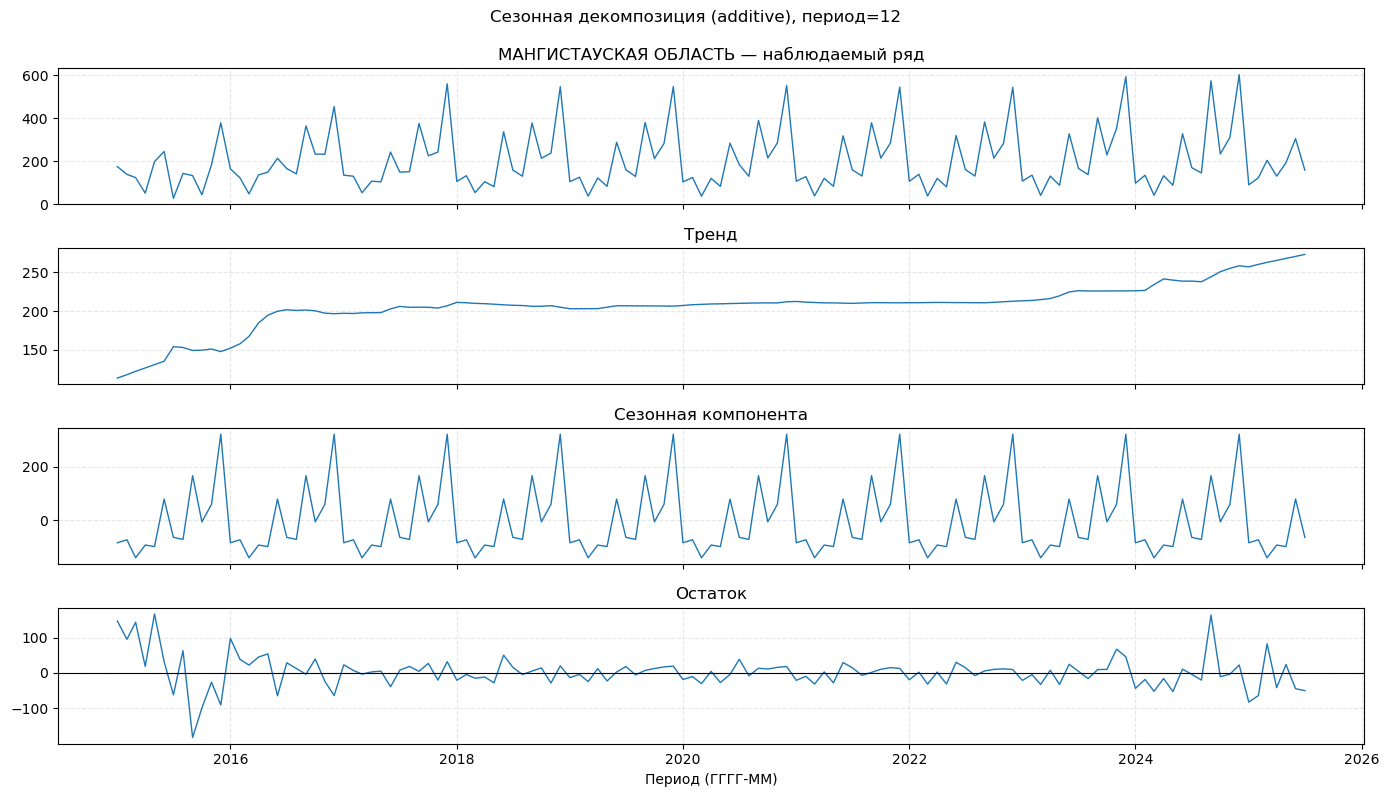

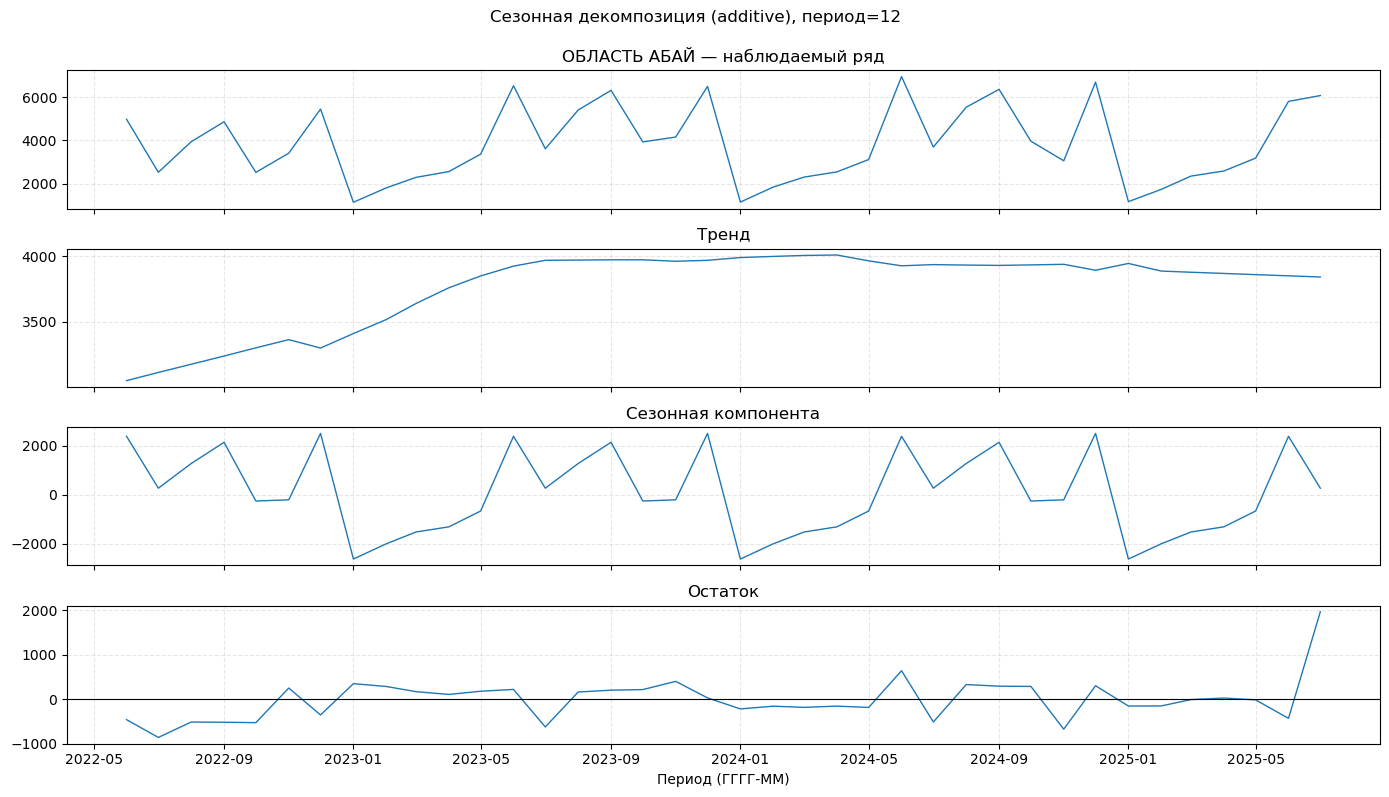

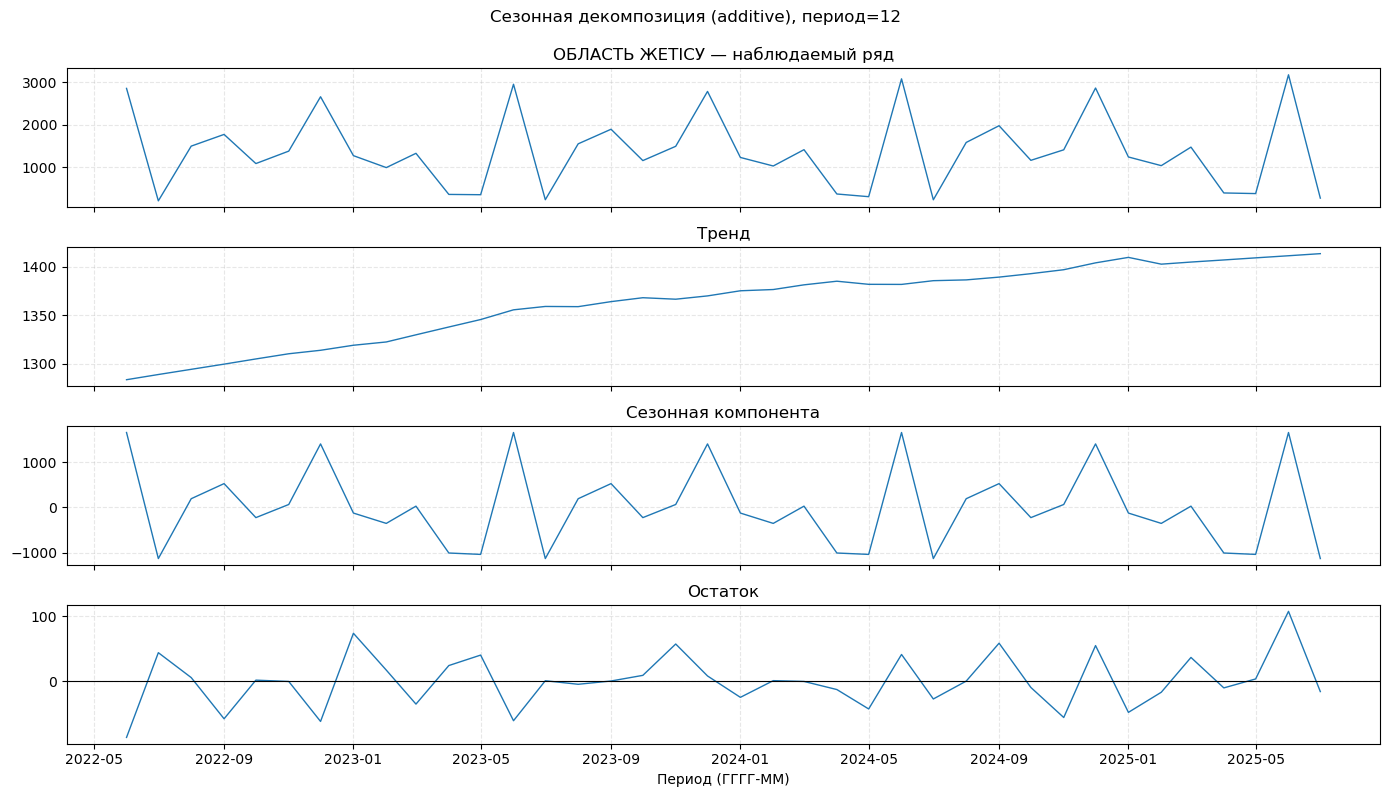

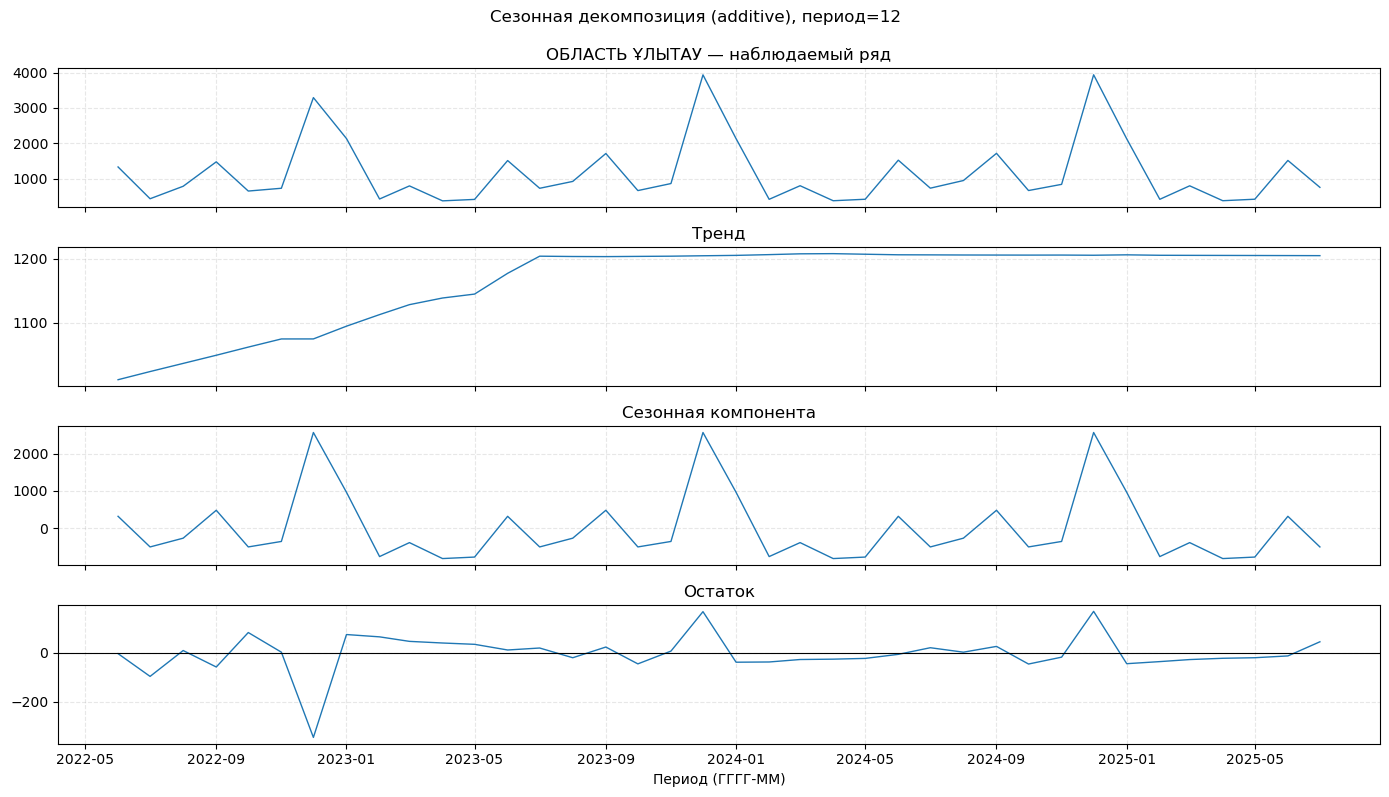

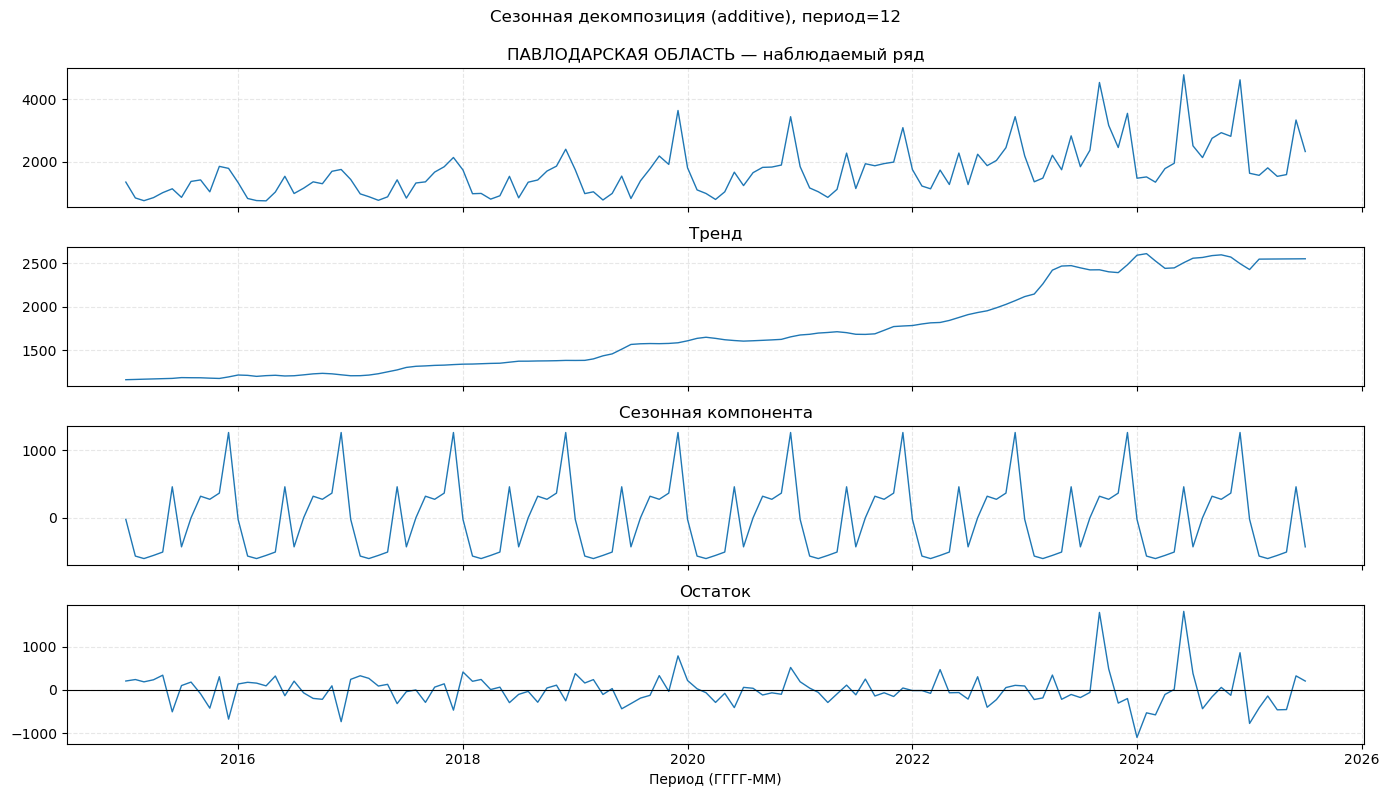

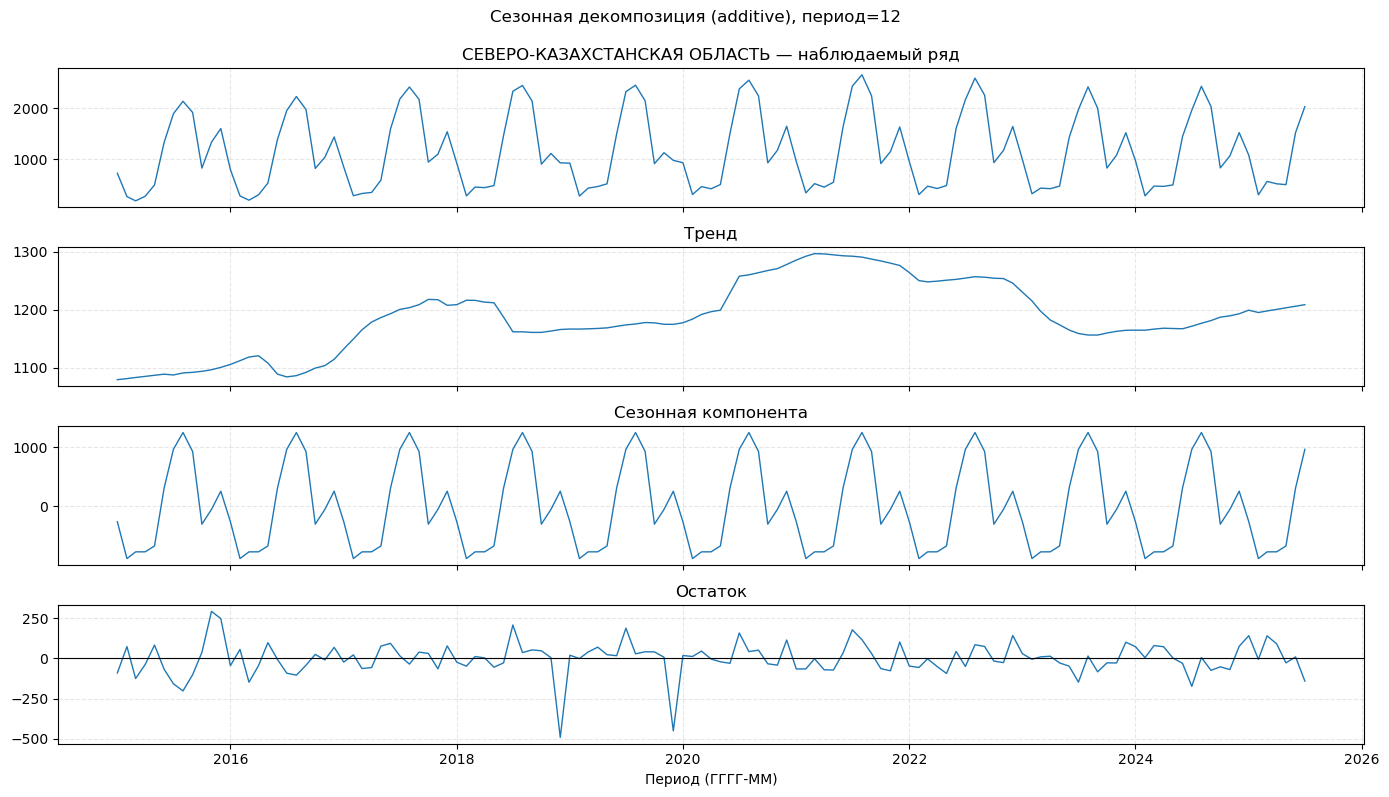

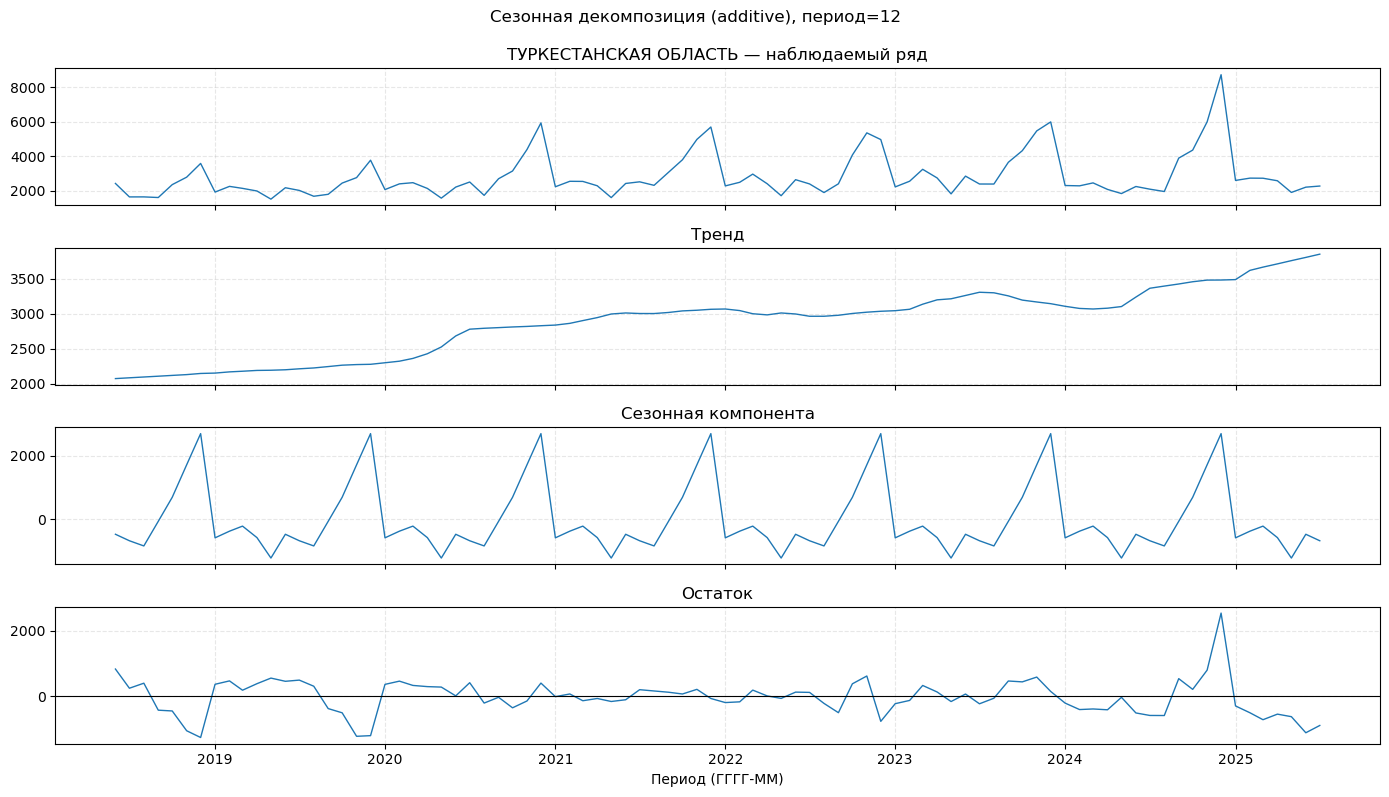

In [15]:
# === Сезонная декомпозиция по регионам ===

value_col = "Лошади"     # ← при необходимости замените
model = "additive"         # варианты: "additive" или "multiplicative"
season_period = 12         # месячная сезонность
min_len = 2 * season_period  # минимальная длина ряда для декомпозиции

# подготовка дат
df_dec = df.copy()
df_dec["Период"] = pd.to_datetime(df_dec["Период"]).dt.to_period("M").dt.to_timestamp()
regions = sorted(df_dec["Регион"].unique())

def decompose_and_plot(s, region_name, model="additive", period=12, save_png=False):
    """
    s: pd.Series с индексом-датой (MS) и значениями показателя по одному региону
    """
    # делаем ежемесячную частоту и лёгкую интерполяцию, чтобы не падало на мелких пропусках
    s = s.asfreq("MS")
    if s.isna().any():
        s = s.interpolate(method="linear", limit_direction="both")

    res = seasonal_decompose(s, model=model, period=period, extrapolate_trend="freq")

    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(res.observed, lw=1)
    axes[0].set_title(f"{region_name} — наблюдаемый ряд")
    axes[0].grid(True, ls="--", alpha=0.3)

    axes[1].plot(res.trend, lw=1)
    axes[1].set_title("Тренд")
    axes[1].grid(True, ls="--", alpha=0.3)

    axes[2].plot(res.seasonal, lw=1)
    axes[2].set_title("Сезонная компонента")
    axes[2].grid(True, ls="--", alpha=0.3)

    axes[3].plot(res.resid, lw=1)
    axes[3].axhline(0, color="black", lw=0.8)
    axes[3].set_title("Остаток")
    axes[3].grid(True, ls="--", alpha=0.3)

    fig.suptitle(f"Сезонная декомпозиция ({model}), период={period}", y=0.99)
    plt.xlabel("Период (ГГГГ-ММ)")
    plt.tight_layout()
    if save_png:
        fname = f"decomp_{value_col}_{region_name}.png".replace(" ", "_")
        plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

# цикл по регионам
for reg in regions:
    s = (df_dec.loc[df_dec["Регион"] == reg]
               .sort_values("Период")
               .set_index("Период")[value_col]
               .dropna())

    if len(s) < min_len:
        print(f"Пропуск декомпозиции: {reg} (ряд короче {min_len} наблюдений)")
        continue

    try:
        decompose_and_plot(s, reg, model=model, period=season_period, save_png=False)
    except Exception as e:
        print(f"Не удалось выполнить декомпозицию для {reg}: {e}")


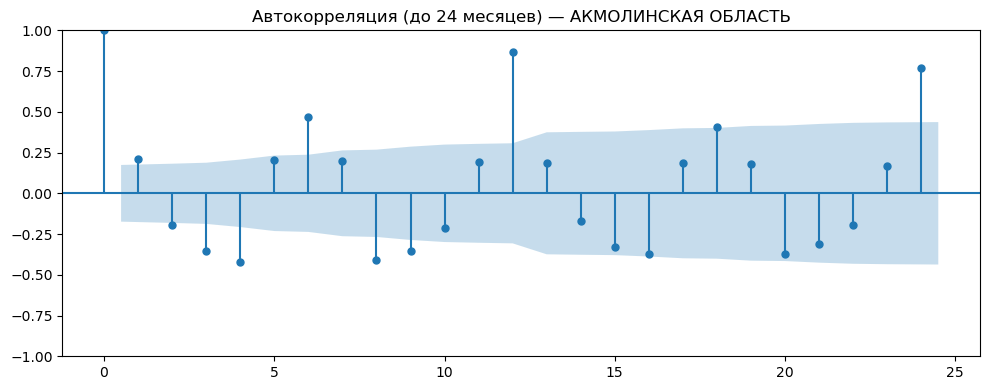

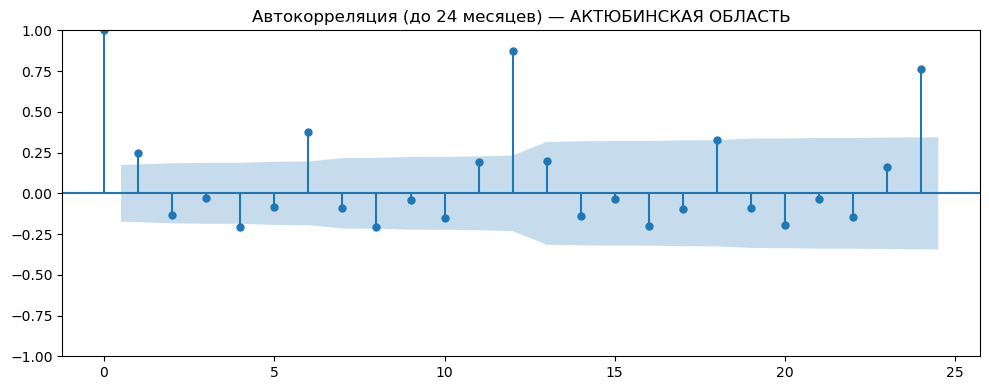

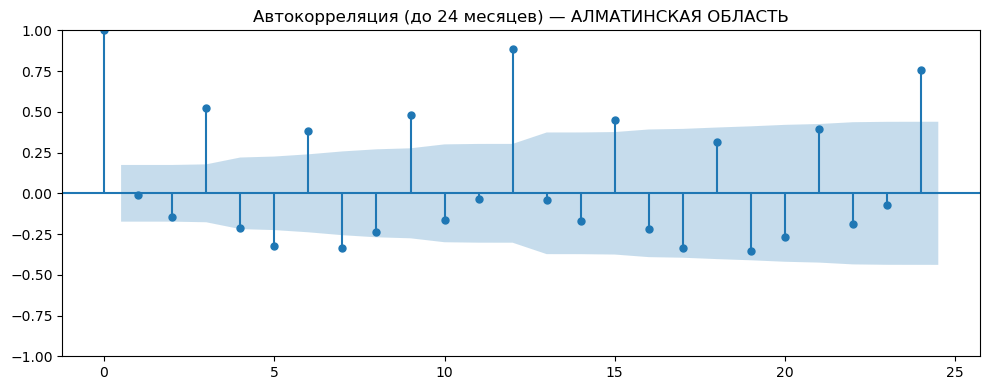

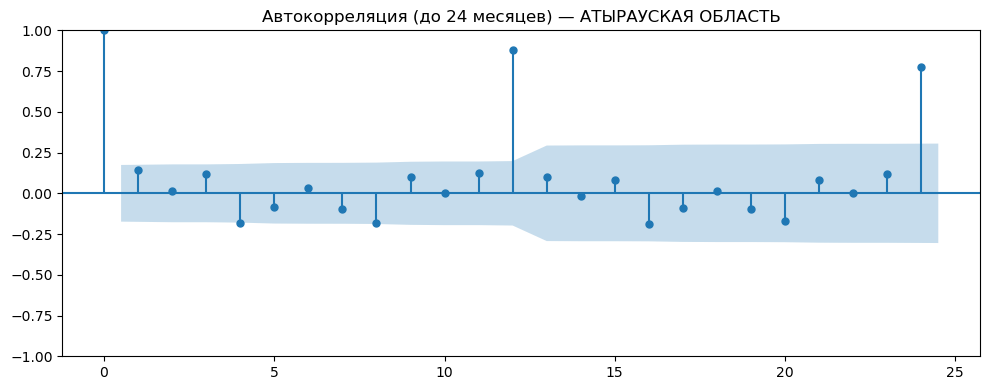

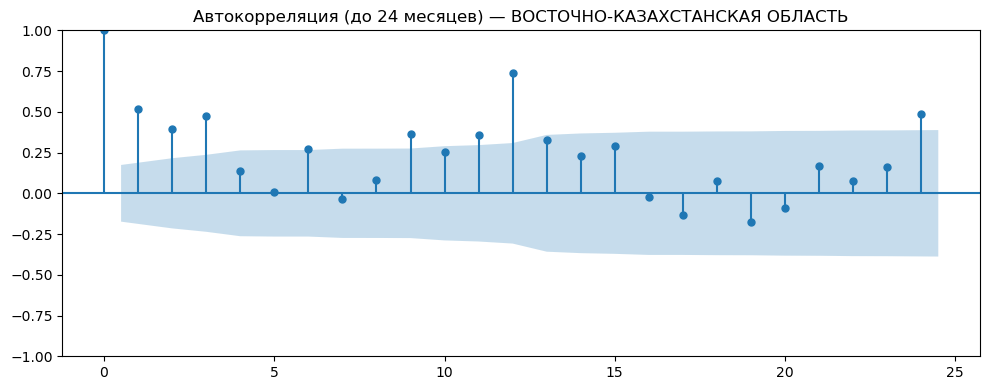

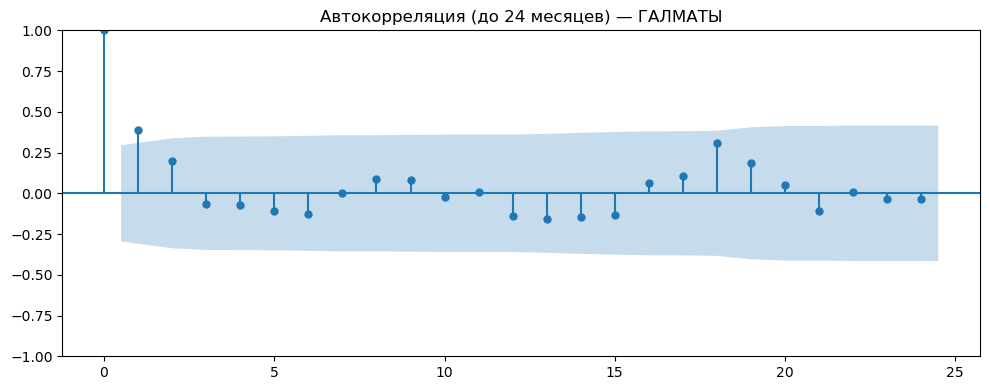

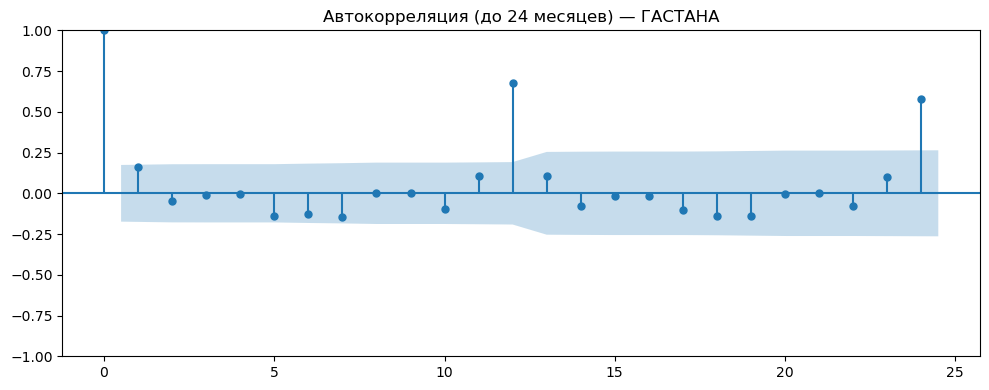

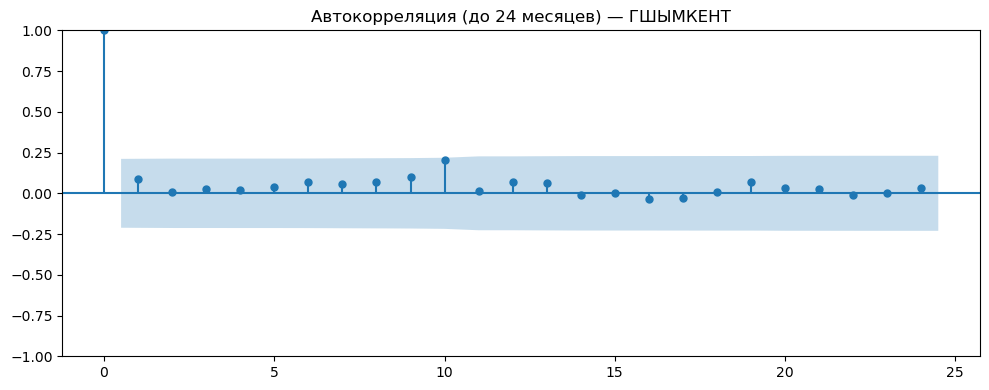

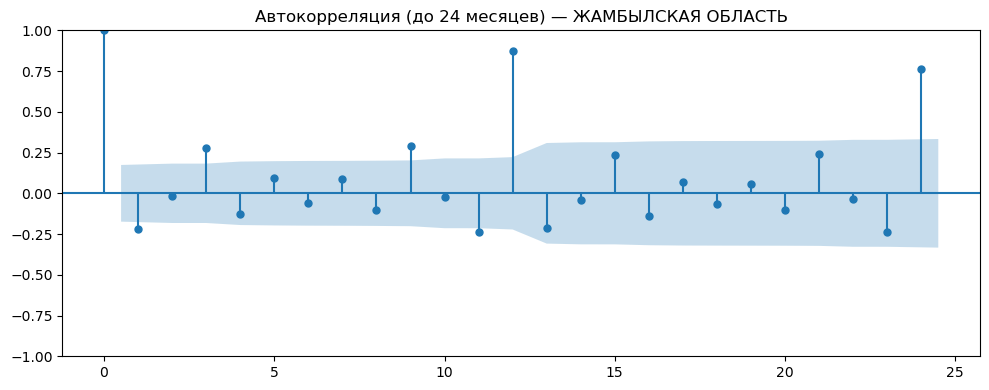

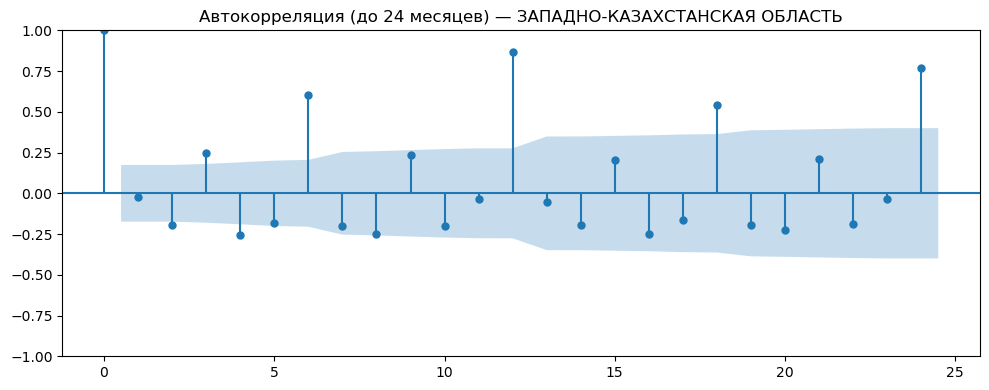

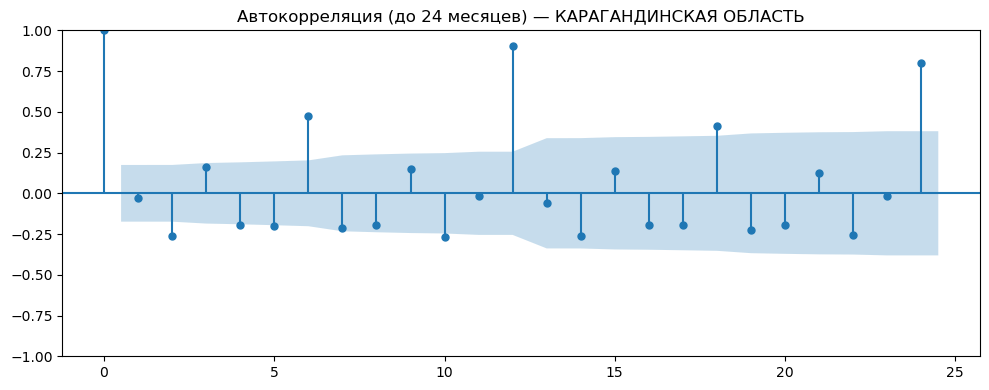

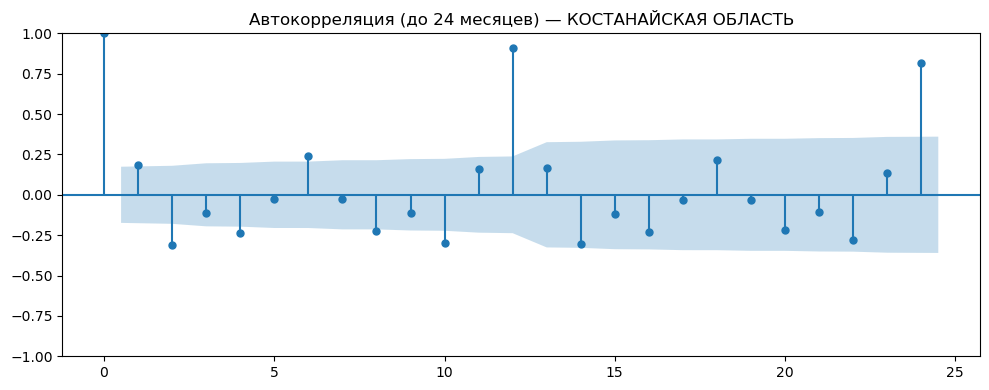

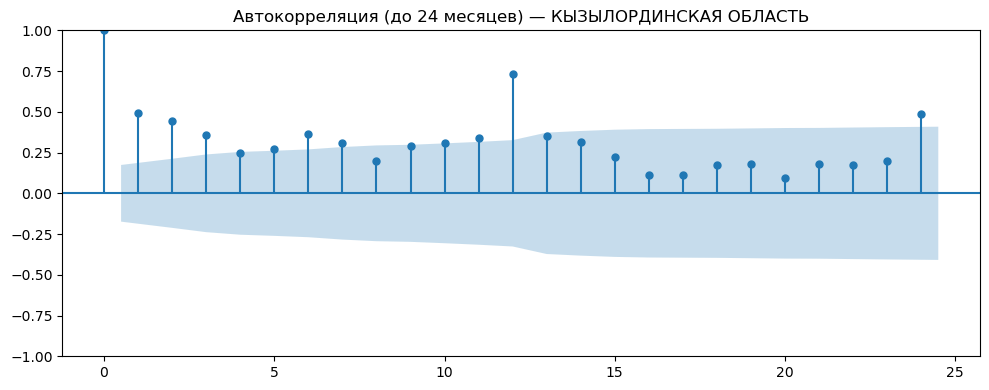

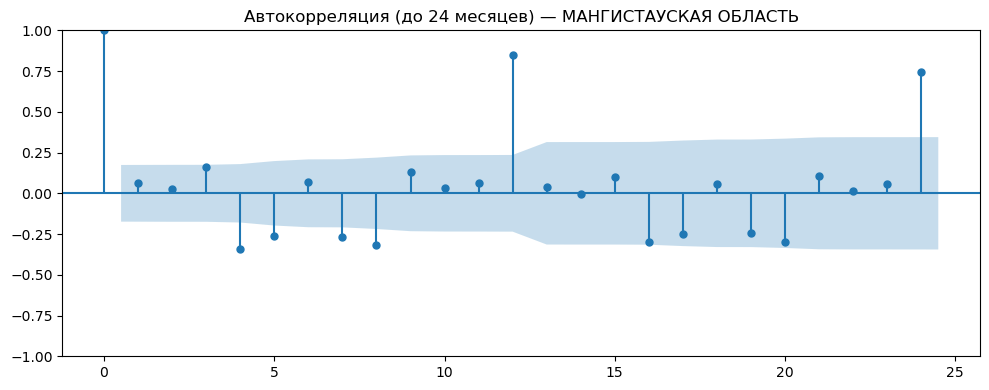

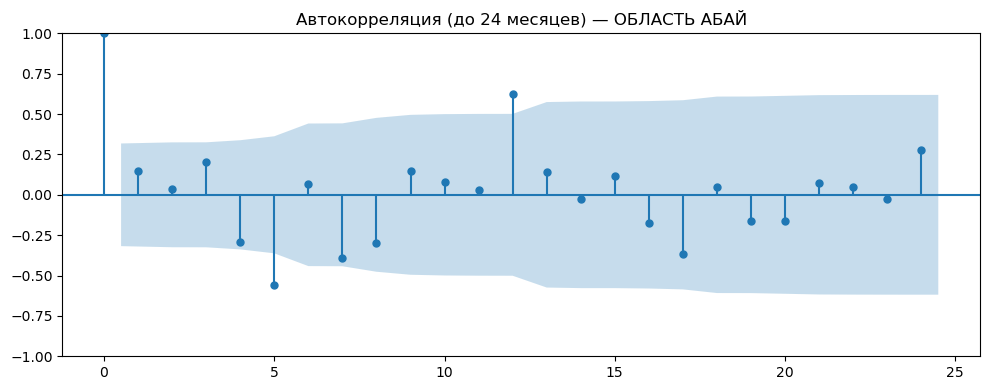

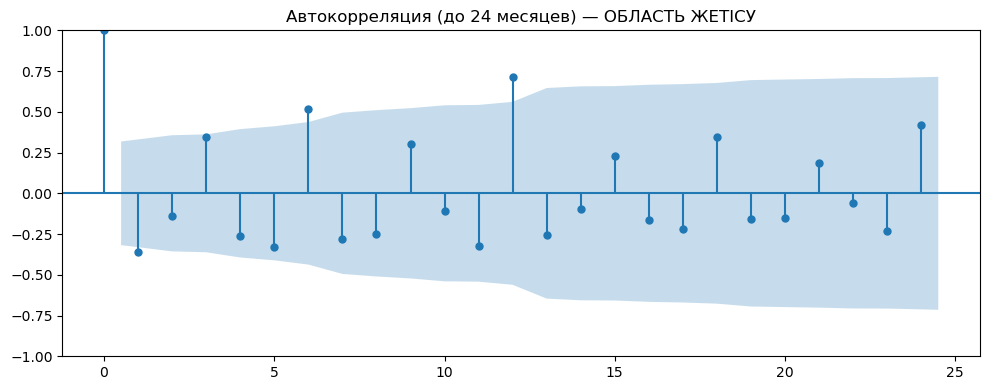

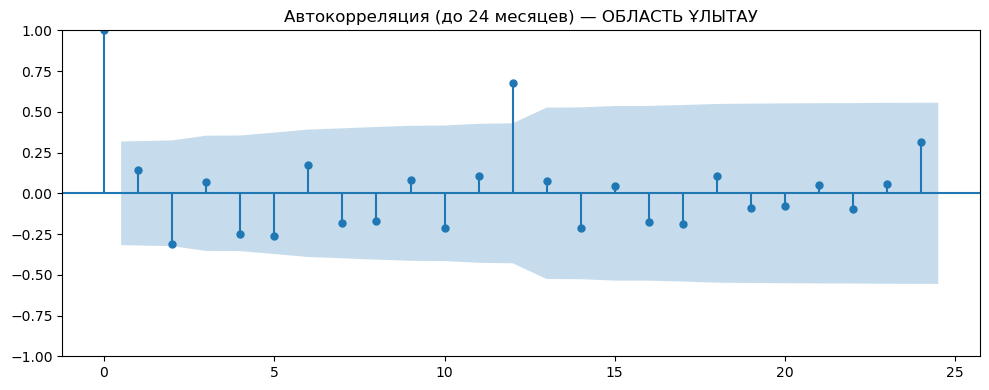

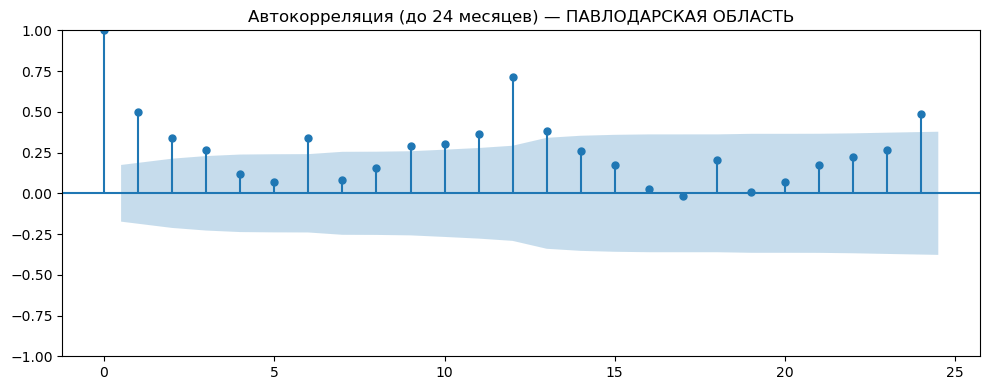

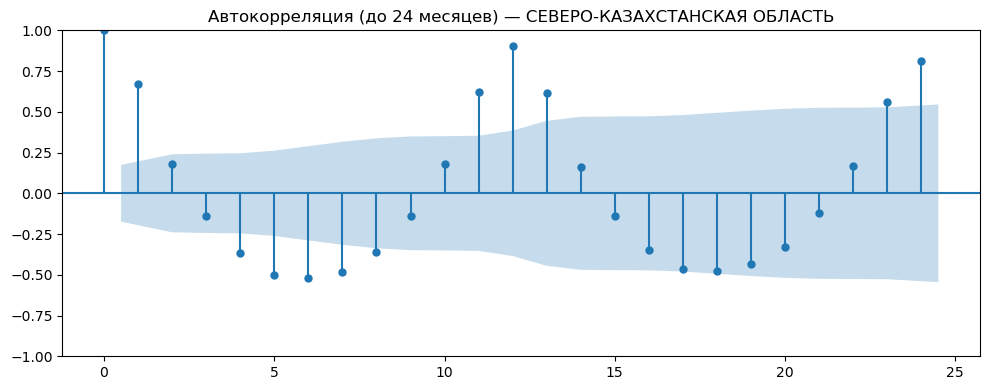

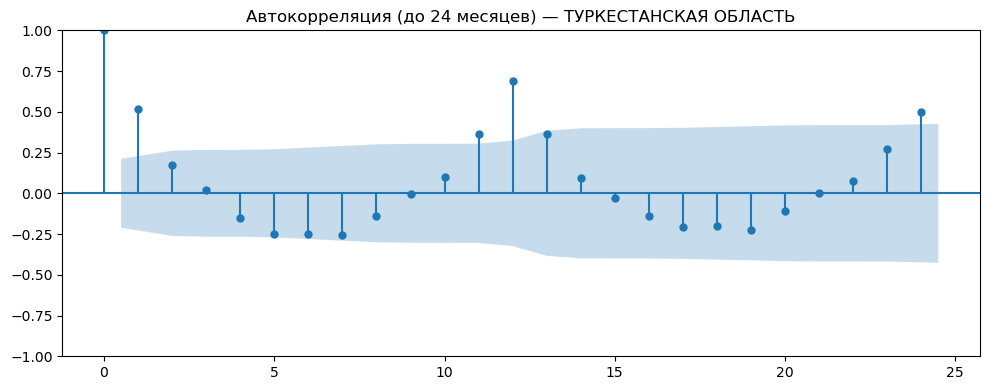

In [16]:
value_col = "Лошади"  # название вашего показателя
max_lags = 24

# Подготовка
df_acf = df.copy()
df_acf["Период"] = pd.to_datetime(df_acf["Период"]).dt.to_period("M").dt.to_timestamp()
regions = sorted(df_acf["Регион"].unique())

# Построение графиков ACF
for reg in regions:
    series = (df_acf.loc[df_acf["Регион"] == reg]
                     .sort_values("Период")
                     .set_index("Период")[value_col]
                     .dropna())

    if len(series) < max_lags + 1:
        print(f"Пропуск ACF: {reg} (ряд слишком короткий)")
        continue

    fig, ax = plt.subplots(figsize=(10,4))
    plot_acf(series, lags=max_lags, ax=ax)
    ax.set_title(f"Автокорреляция (до {max_lags} месяцев) — {reg}")
    plt.tight_layout()
    plt.show()


In [17]:
# === ADF-тест по регионам (с проверкой разностей) ===

value_col = "Лошади"        # ← замените на ваш столбец с показателем
alpha = 0.05                  # уровень значимости
season = 12                   # месячная сезонность
min_len = 24                  # минимальная длина ряда для теста

df_adf = df.copy()
df_adf["Период"] = pd.to_datetime(df_adf["Период"]).dt.to_period("M").dt.to_timestamp()
regions = sorted(df_adf["Регион"].unique())

rows = []
for reg in regions:
    s = (df_adf.loc[df_adf["Регион"] == reg, ["Период", value_col]]
                .dropna()
                .sort_values("Период")
                .set_index("Период")[value_col])

    if len(s) < min_len:
        rows.append({
            "Регион": reg,
            "N": len(s),
            "ADF_p": np.nan, "ADF_stat": np.nan, "Стационарен?": "ряд слишком короткий",
            "ADF_p(Δ)": np.nan, "ADF_p(Δ12)": np.nan,
            "Рекомендация d": np.nan, "Рекомендация D": np.nan
        })
        continue

    # базовый ADF
    res0 = adfuller(s, autolag="AIC")
    p0, stat0, lags0, nobs0 = res0[1], res0[0], res0[2], res0[3]
    st0 = "Да" if p0 < alpha else "Нет"

    # первая разность
    s_diff = s.diff().dropna()
    p1 = adfuller(s_diff, autolag="AIC")[1] if len(s_diff) >= min_len-1 else np.nan
    st1 = (p1 < alpha) if pd.notna(p1) else None

    # сезонная разность
    s_sdiff = s.diff(season).dropna()
    pS = adfuller(s_sdiff, autolag="AIC")[1] if len(s_sdiff) >= min_len-1 else np.nan
    stS = (pS < alpha) if pd.notna(pS) else None

    # простая рекомендация по порядкам разностей
    # если исходный ряд нестационарен, но Δ стационарна → d=1; иначе d=0
    rec_d = 1 if (p0 >= alpha and pd.notna(p1) and p1 < alpha) else 0
    # если исходный ряд нестационарен по сезонности, а Δ12 стационарна → D=1; иначе D=0
    rec_D = 1 if (pd.notna(pS) and pS < alpha and (p0 >= alpha)) else 0

    rows.append({
        "Регион": reg,
        "N": len(s),
        "ADF_p": round(p0, 4),
        "ADF_stat": round(stat0, 3),
        "Стационарен?": st0,
        "ADF_p(Δ)": round(p1, 4) if pd.notna(p1) else np.nan,
        "ADF_p(Δ12)": round(pS, 4) if pd.notna(pS) else np.nan,
        "Рекомендация d": rec_d,
        "Рекомендация D": rec_D
    })

adf_table = pd.DataFrame(rows).sort_values(["Стационарен?", "ADF_p"])
display(adf_table)

print(f"\nПорог значимости α = {alpha}. Значение p < α → отвергаем H0 о наличии единичного корня (ряд стационарен).")
print("Столбцы ADF_p(Δ) и ADF_p(Δ12) даны для удобства подбора порядков разностей (d, D) в SARIMA.")


,Регион,N,ADF_p,ADF_stat,Стационарен?,ADF_p(Δ),ADF_p(Δ12),Рекомендация d,Рекомендация D
7,ГШЫМКЕНТ,86,0.0000,-8.365,Да,0.0001,0.0000,0,0
15,ОБЛАСТЬ ЖЕТІСУ,38,0.0000,-5.480,Да,0.0000,0.0011,0,0
16,ОБЛАСТЬ ҰЛЫТАУ,38,0.0000,-7.278,Да,0.0000,0.0023,0,0
5,ГАЛМАТЫ,44,0.0186,-3.224,Да,0.0000,0.0025,0,0
14,ОБЛАСТЬ АБАЙ,38,0.0261,-3.106,Да,0.0000,0.0212,0,0
18,СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,127,0.3392,-1.885,Нет,0.0046,0.0016,1,1
13,МАНГИСТАУСКАЯ ОБЛАСТЬ,127,0.3589,-1.844,Нет,0.0000,0.0010,1,1
8,ЖАМБЫЛСКАЯ ОБЛАСТЬ,127,0.4177,-1.726,Нет,0.0000,0.0136,1,1
10,КАРАГАНДИНСКАЯ ОБЛАСТЬ,127,0.5266,-1.514,Нет,0.1775,0.0509,0,0
4,ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,127,0.5934,-1.377,Нет,0.0461,0.1733,1,0



Порог значимости α = 0.05. Значение p < α → отвергаем H0 о наличии единичного корня (ряд стационарен).
Столбцы ADF_p(Δ) и ADF_p(Δ12) даны для удобства подбора порядков разностей (d, D) в SARIMA.
